# LLM Merging

## First experiment

### first experiment is apply fourier series formula for neural network

#### First step is simple functions

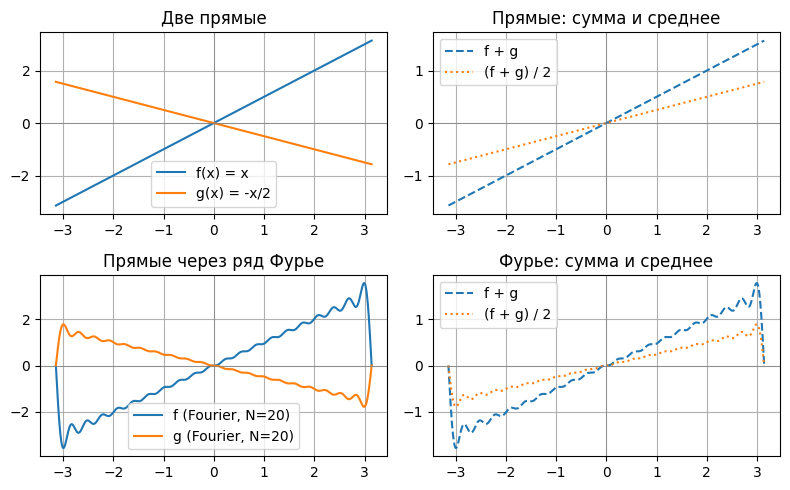

In [1]:
import numpy as np
from matplotlib import pyplot

x = np.linspace(-np.pi, np.pi, 1000)

f_line = x
g_line = -x / 2
sum_line = f_line + g_line
avg_line = (f_line + g_line) / 2

N = 20
f = np.zeros_like(x)
g = np.zeros_like(x)
for n in range(1, N + 1):
    coef = (-1)**(n + 1) / n * np.sin(n * x)
    f += 2 * coef
    g += -1 * coef
sum_fg = f + g
avg_fg = (f + g) / 2

fig, ax = pyplot.subplots(2, 2, figsize=(8, 5))

ax[0, 0].plot(x, f_line, label='f(x) = x')
ax[0, 0].plot(x, g_line, label='g(x) = -x/2')
ax[0, 0].set_title('Две прямые')
ax[0, 0].legend()
ax[0, 0].grid(True)

ax[0, 1].plot(x, sum_line, label='f + g', linestyle='--')
ax[0, 1].plot(x, avg_line, label='(f + g) / 2', linestyle=':')
ax[0, 1].set_title('Прямые: сумма и среднее')
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].plot(x, f, label='f (Fourier, N=20)')
ax[1, 0].plot(x, g, label='g (Fourier, N=20)')
ax[1, 0].set_title('Прямые через ряд Фурье')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].plot(x, sum_fg, label='f + g', linestyle='--')
ax[1, 1].plot(x, avg_fg, label='(f + g) / 2', linestyle=':')
ax[1, 1].set_title('Фурье: сумма и среднее')
ax[1, 1].legend()
ax[1, 1].grid(True)

for a in ax.flat:
    a.axhline(0, color='gray', linewidth=0.5)
    a.axvline(0, color='gray', linewidth=0.5)

pyplot.tight_layout()
pyplot.show()

## Прямые

$$f(x) = x$$

$$g(x) = -\frac{x}{2}$$

$$f(x) + g(x) = \frac{x}{2}$$

$$\frac{f(x) + g(x)}{2} = \frac{x}{4}$$

---

## Ряды Фурье на $[-\pi, \pi]$

$$f(x) = x = 2\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$g(x) = -\frac{x}{2} = -\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$f(x) + g(x) = \sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$\frac{f(x) + g(x)}{2} = \frac{1}{2}\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

---

## Частичная сумма (то, что считается в коде, $N=20$)

$$f_N(x) = 2\sum_{n=1}^{N} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$g_N(x) = -\sum_{n=1}^{N} \frac{(-1)^{n+1}}{n}\sin(nx)$$


#### Second step is arifmetic sums for different functions

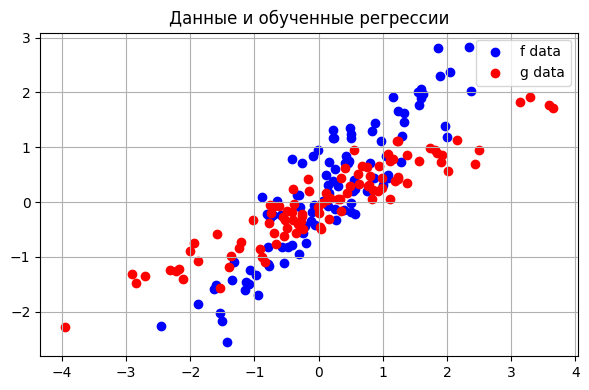

In [2]:
from matplotlib import pyplot as plt

np.random.seed(0)

n_samples = 100

X_f = np.random.normal(0.1, 1.0, n_samples).reshape(-1, 1)
y_f = X_f.ravel() + np.random.normal(0, 0.5, n_samples)

X_g = np.random.normal(0.2, 1.5, n_samples).reshape(-1, 1)
y_g = X_g.ravel() / 2 + np.random.normal(0, 0.3, n_samples)

plt.figure(figsize=(6, 4))
plt.scatter(X_f, y_f, color='blue', label='f data')
plt.scatter(X_g, y_g, color='red', label='g data')

plt.title("Данные и обученные регрессии")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Train

f(x) = 1.0877 * x + 0.0607
g(x) = 0.5281 * x + -0.0454
R^2 (f) train: 0.8174, test: 0.7662
R^2 (g) train: 0.8658, test: 0.9304


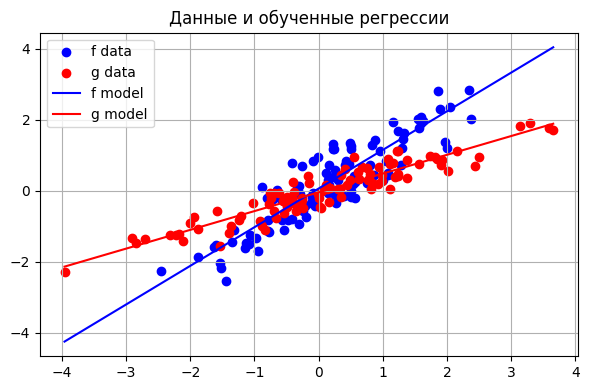

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_f, y_f, test_size=0.2, random_state=0)
X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(X_g, y_g, test_size=0.2, random_state=0)

model_f = LinearRegression().fit(X_f_train, y_f_train)
model_g = LinearRegression().fit(X_g_train, y_g_train)

print(f"f(x) = {model_f.coef_[0]:.4f} * x + {model_f.intercept_:.4f}")
print(f"g(x) = {model_g.coef_[0]:.4f} * x + {model_g.intercept_:.4f}")

print(f"R^2 (f) train: {model_f.score(X_f_train, y_f_train):.4f}, test: {model_f.score(X_f_test, y_f_test):.4f}")
print(f"R^2 (g) train: {model_g.score(X_g_train, y_g_train):.4f}, test: {model_g.score(X_g_test, y_g_test):.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(X_f, y_f, color='blue', label='f data')
plt.scatter(X_g, y_g, color='red', label='g data')

x_line = np.linspace(min(X_f.min(), X_g.min()), max(X_f.max(), X_g.max()), 100).reshape(-1, 1)
plt.plot(x_line, model_f.predict(x_line), color='blue', label='f model')
plt.plot(x_line, model_g.predict(x_line), color='red', label='g model')

plt.title("Данные и обученные регрессии")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Train model

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Объединяем данные f и g
X_all = np.vstack([X_f, X_g])
y_all = np.concatenate([y_f, y_g])

# Делим объединённые данные на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=0
)

# Обучаем одну линейную регрессию
model_all = LinearRegression().fit(X_train, y_train)

#### Calculate medium parameters

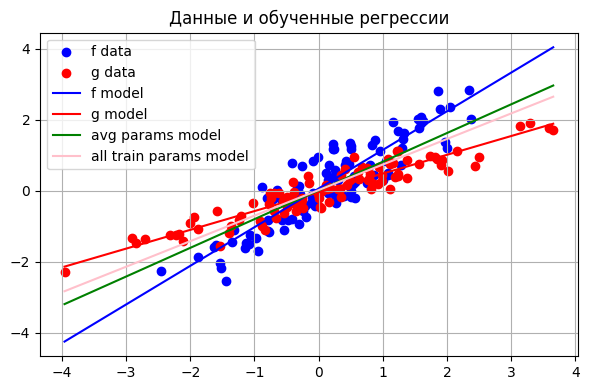

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(6, 4))
plt.scatter(X_f, y_f, color='blue', label='f data')
plt.scatter(X_g, y_g, color='red', label='g data')

x_line = np.linspace(
    min(X_f.min(), X_g.min()),
    max(X_f.max(), X_g.max()),
    100
).reshape(-1, 1)

# Создаём модель, параметры которой — среднее параметров model_f и model_g
model_avg = LinearRegression()

model_avg.coef_ = (model_f.coef_ + model_g.coef_) / 2
model_avg.intercept_ = (model_f.intercept_ + model_g.intercept_) / 2
model_avg.n_features_in_ = model_f.n_features_in_

# Предсказания моделей
y_f_pred = model_f.predict(x_line)
y_g_pred = model_g.predict(x_line)
y_avg_pred = model_avg.predict(x_line)
y_all_pred = model_all.predict(x_line)

plt.plot(x_line, y_f_pred, color='blue', label='f model')
plt.plot(x_line, y_g_pred, color='red', label='g model')
plt.plot(x_line, y_avg_pred, color='green', label='avg params model')
plt.plot(x_line, y_all_pred, color='pink', label='all train params model')

plt.title("Данные и обученные регрессии")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error

# MAE на f_test
mae_f_test = mean_absolute_error(
    y_f_test,
    model_f.predict(X_f_test)
)

mae_avg_on_f_test = mean_absolute_error(
    y_f_test,
    model_avg.predict(X_f_test)
)

mae_all_on_f_test = mean_absolute_error(
    y_f_test,
    model_all.predict(X_f_test)
)

# MAE на g_test
mae_g_test = mean_absolute_error(
    y_g_test,
    model_g.predict(X_g_test)
)

mae_avg_on_g_test = mean_absolute_error(
    y_g_test,
    model_avg.predict(X_g_test)
)

mae_all_on_g_test = mean_absolute_error(
    y_g_test,
    model_all.predict(X_g_test)
)

print(f"MAE f model on f test: {mae_f_test:.2f}")
print(f"MAE avg model on f test: {mae_avg_on_f_test:.2f}")
print(f"MAE all model on f test: {mae_all_on_f_test:.2f}")

print(f"MAE g model on g test: {mae_g_test:.2f}")
print(f"MAE avg model on g test: {mae_avg_on_g_test:.2f}")
print(f"MAE all model on g test: {mae_all_on_g_test:.2f}")

MAE f model on f test: 0.42
MAE avg model on f test: 0.38
MAE all model on f test: 0.41
MAE g model on g test: 0.18
MAE avg model on g test: 0.40
MAE all model on g test: 0.32


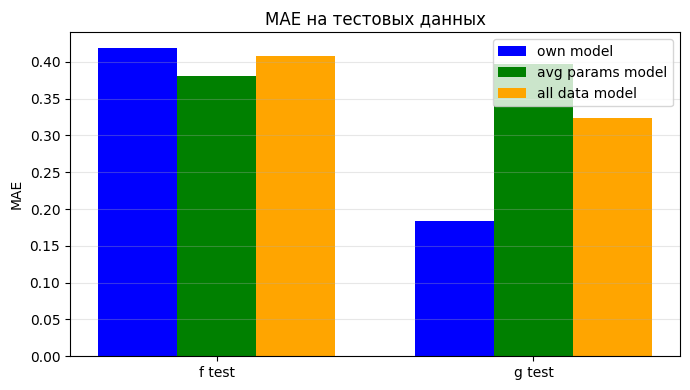

In [7]:
# Bar plot
labels = ["f test", "g test"]

own_model_scores = [mae_f_test, mae_g_test]
avg_model_scores = [mae_avg_on_f_test, mae_avg_on_g_test]
all_model_scores = [mae_all_on_f_test, mae_all_on_g_test]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(7, 4))

plt.bar(
    x - width,
    own_model_scores,
    width,
    label="own model",
    color="blue"
)

plt.bar(
    x,
    avg_model_scores,
    width,
    label="avg params model",
    color="green"
)

plt.bar(
    x + width,
    all_model_scores,
    width,
    label="all data model",
    color="orange"
)

plt.xticks(x, labels)
plt.ylabel("MAE")
plt.title("MAE на тестовых данных")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Рассмотри разные ситуации распределения данных

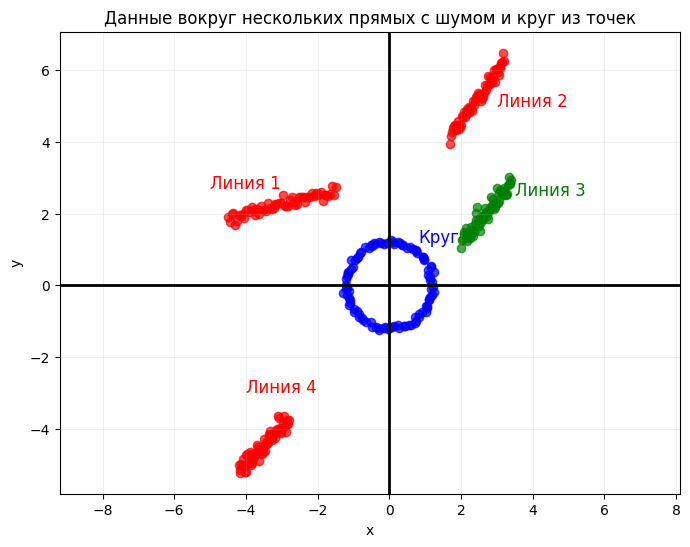

In [8]:
import numpy as np
from matplotlib import pyplot as plt

rng = np.random.default_rng(42)

def make_noisy_line(x_start, x_end, k, b, n=50, noise=0.15):
    x = np.linspace(x_start, x_end, n)
    y = k * x + b + rng.normal(0, noise, size=n)
    return x, y


def make_noisy_circle(x_center, y_center, radius, n=100, noise=0.05):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    x = x_center + radius * np.cos(angles)
    y = y_center + radius * np.sin(angles)

    # небольшой шум, чтобы точки были не идеально на окружности
    x = x + rng.normal(0, noise, size=n)
    y = y + rng.normal(0, noise, size=n)

    return x, y


# Линия 1: слева сверху
x1, y1 = make_noisy_line(
    x_start=-4.5,
    x_end=-1.5,
    k=0.25,
    b=3.0,
    n=60,
    noise=0.12
)

# Линия 2: справа сверху
x2, y2 = make_noisy_line(
    x_start=1.7,
    x_end=3.2,
    k=1.4,
    b=1.8,
    n=60,
    noise=0.15
)

# Линия 3: справа посередине
x3, y3 = make_noisy_line(
    x_start=2.0,
    x_end=3.4,
    k=1.2,
    b=-1.2,
    n=60,
    noise=0.15
)

# Линия 4: слева снизу
x4, y4 = make_noisy_line(
    x_start=-4.2,
    x_end=-2.8,
    k=1.1,
    b=-0.6,
    n=60,
    noise=0.15
)

# Круг из точек
xc, yc = make_noisy_circle(
    x_center=0.0,
    y_center=0.0,
    radius=1.2,
    n=100,
    noise=0.04
)


plt.figure(figsize=(8, 6))

plt.scatter(x1, y1, color="red", alpha=0.7)
plt.scatter(x2, y2, color="red", alpha=0.7)
plt.scatter(x3, y3, color="green", alpha=0.7)
plt.scatter(x4, y4, color="red", alpha=0.7)

# Отрисовка круга
plt.scatter(xc, yc, color="blue", alpha=0.7)

# Оси
plt.axhline(0, color="black", linewidth=2)
plt.axvline(0, color="black", linewidth=2)

# Подписи линий
plt.text(-5, 2.7, "Линия 1", color="red", fontsize=12)
plt.text(3, 5, "Линия 2", color="red", fontsize=12)
plt.text(3.5, 2.5, "Линия 3", color="green", fontsize=12)
plt.text(-4.0, -3, "Линия 4", color="red", fontsize=12)

# Подпись круга
plt.text(0.8, 1.2, "Круг", color="blue", fontsize=12)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Данные вокруг нескольких прямых с шумом и круг из точек")

plt.grid(alpha=0.2)
plt.axis("equal")
plt.show()

### Для избавление от перекоса в данных объеденим большое скопление в данных в кластера

In [9]:
from sklearn.cluster import DBSCAN
import numpy as np
from matplotlib import pyplot as plt


def dbscan_for_one_set(x, y, name, eps=0.25, min_samples=3):
    points = np.column_stack([x, y])

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = dbscan.fit_predict(points)

    n_clusters = len(set(labels) - {-1})
    n_noise = np.sum(labels == -1)

    print(f"{name}: кластеров = {n_clusters}, шумовых точек = {n_noise}")

    return points, labels


# Запускаем DBSCAN отдельно для каждого набора точек
points_1, labels_1 = dbscan_for_one_set(x1, y1, "Линия 1", eps=0.1, min_samples=3)
points_2, labels_2 = dbscan_for_one_set(x2, y2, "Линия 2", eps=0.1, min_samples=3)
points_3, labels_3 = dbscan_for_one_set(x3, y3, "Линия 3", eps=0.1, min_samples=3)
points_4, labels_4 = dbscan_for_one_set(x4, y4, "Линия 4", eps=0.1, min_samples=3)
points_c, labels_c = dbscan_for_one_set(xc, yc, "Круг", eps=0.1, min_samples=3)

Линия 1: кластеров = 11, шумовых точек = 22
Линия 2: кластеров = 7, шумовых точек = 10
Линия 3: кластеров = 7, шумовых точек = 18
Линия 4: кластеров = 6, шумовых точек = 16
Круг: кластеров = 18, шумовых точек = 30


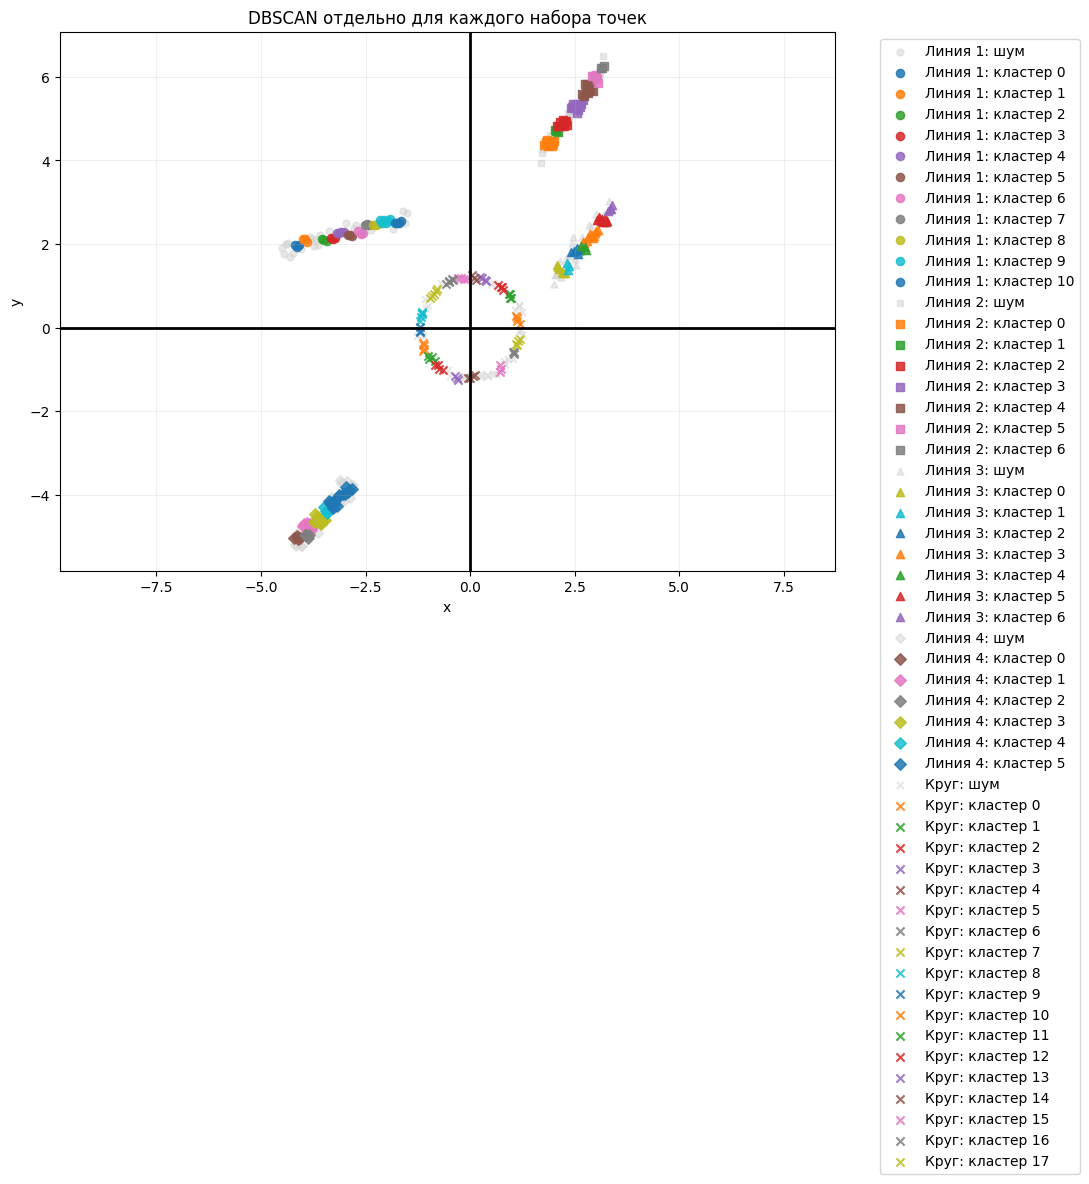

In [10]:
def plot_dbscan_result(points, labels, title_prefix, marker="o"):
    unique_labels = sorted(set(labels))

    for cluster_label in unique_labels:
        cluster_points = points[labels == cluster_label]

        if cluster_label == -1:
            plt.scatter(
                cluster_points[:, 0],
                cluster_points[:, 1],
                color="lightgray",
                s=25,
                alpha=0.5,
                marker=marker,
                label=f"{title_prefix}: шум"
            )
        else:
            plt.scatter(
                cluster_points[:, 0],
                cluster_points[:, 1],
                s=35,
                alpha=0.85,
                marker=marker,
                label=f"{title_prefix}: кластер {cluster_label}"
            )


plt.figure(figsize=(10, 7))

plot_dbscan_result(points_1, labels_1, "Линия 1", marker="o")
plot_dbscan_result(points_2, labels_2, "Линия 2", marker="s")
plot_dbscan_result(points_3, labels_3, "Линия 3", marker="^")
plot_dbscan_result(points_4, labels_4, "Линия 4", marker="D")
plot_dbscan_result(points_c, labels_c, "Круг", marker="x")

# Оси
plt.axhline(0, color="black", linewidth=2)
plt.axvline(0, color="black", linewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("DBSCAN отдельно для каждого набора точек")
plt.grid(alpha=0.2)
plt.axis("equal")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### По данным графикам я выявил различные ситуации двух задач
### 1-я задача - зеленая линия
### 2-я задача - красная линия
### По объедение двух Линейных моделей имеет смысл если угол между данными и смещение почти равны или похожи

In [11]:
import numpy as np
import pandas as pd
from itertools import combinations


def calc_angles_between_clusters(points, labels, object_name):
    cluster_centers = []

    unique_labels = sorted(set(labels))

    print(f"\n{object_name}")
    print("Метки DBSCAN:", unique_labels)

    for cluster_label in unique_labels:
        # Шум DBSCAN пропускаем
        if cluster_label == -1:
            continue

        cluster_points = points[labels == cluster_label]

        if len(cluster_points) == 0:
            continue

        center_x = cluster_points[:, 0].mean()
        center_y = cluster_points[:, 1].mean()

        cluster_centers.append({
            "cluster": cluster_label,
            "center_x": center_x,
            "center_y": center_y,
            "n_points": len(cluster_points)
        })

    centers_df = pd.DataFrame(cluster_centers)

    print(f"Количество кластеров без шума: {len(centers_df)}")

    if len(centers_df) < 2:
        print("Недостаточно кластеров для расчёта углов")
        return pd.DataFrame(), centers_df

    results = []

    for c1, c2 in combinations(cluster_centers, 2):
        dx = c2["center_x"] - c1["center_x"]
        dy = c2["center_y"] - c1["center_y"]

        if dx == 0:
            angle_signed = 90.0
        else:
            angle_signed = np.degrees(np.arctan(dy / dx))
            
        angle_0_180 = angle_signed % 180
        angle_to_x = min(angle_0_180, 180 - angle_0_180)

        results.append({
            "object": object_name,

            "cluster_1": c1["cluster"],
            "cluster_2": c2["cluster"],

            "cluster_1_center_x": c1["center_x"],
            "cluster_1_center_y": c1["center_y"],
            "cluster_2_center_x": c2["center_x"],
            "cluster_2_center_y": c2["center_y"],

            "cluster_1_n_points": c1["n_points"],
            "cluster_2_n_points": c2["n_points"],

            "dx": dx,
            "dy": dy,

            "angle_signed_deg": angle_signed,
            "angle_0_180_deg": angle_0_180,
            "angle_to_x_deg": angle_to_x,
        })

    return pd.DataFrame(results), centers_df

In [12]:
angles_between_clusters_1, centers_1 = calc_angles_between_clusters(
    points_1, labels_1, "Линия 1"
)

angles_between_clusters_2, centers_2 = calc_angles_between_clusters(
    points_2, labels_2, "Линия 2"
)

angles_between_clusters_3, centers_3 = calc_angles_between_clusters(
    points_3, labels_3, "Линия 3"
)

angles_between_clusters_4, centers_4 = calc_angles_between_clusters(
    points_4, labels_4, "Линия 4"
)

angles_between_clusters_c, centers_c = calc_angles_between_clusters(
    points_c, labels_c, "Круг"
)


Линия 1
Метки DBSCAN: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Количество кластеров без шума: 11

Линия 2
Метки DBSCAN: [-1, 0, 1, 2, 3, 4, 5, 6]
Количество кластеров без шума: 7

Линия 3
Метки DBSCAN: [-1, 0, 1, 2, 3, 4, 5, 6]
Количество кластеров без шума: 7

Линия 4
Метки DBSCAN: [-1, 0, 1, 2, 3, 4, 5]
Количество кластеров без шума: 6

Круг
Метки DBSCAN: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Количество кластеров без шума: 18


In [13]:
import numpy as np
import pandas as pd
from itertools import combinations

points = np.array([
    [-1,  1],
    [ 1,  1],
    [-1, -1],
    [ 1, -1],
])

point_names = ["A", "B", "C", "D"]

results = []

for i, j in combinations(range(len(points)), 2):
    x_i, y_i = points[i]
    x_j, y_j = points[j]

    dx = x_j - x_i
    dy = y_j - y_i

    # Угол наклона относительно оси X через arctan(dy / dx)
    if dx == 0:
        angle_deg = 90.0
    else:
        angle_deg = np.degrees(np.arctan(dy / dx))

    results.append({
        "point_1": point_names[i],
        "point_2": point_names[j],
        "x_i": x_i,
        "y_i": y_i,
        "x_j": x_j,
        "y_j": y_j,
        "dx": dx,
        "dy": dy,
        "angle_deg": angle_deg,
    })

angles_df = pd.DataFrame(results)
angles_df

,point_1,point_2,x_i,y_i,x_j,y_j,dx,dy,angle_deg
0,A,B,-1,1,1,1,2,0,0.0
1,A,C,-1,1,-1,-1,0,-2,90.0
2,A,D,-1,1,1,-1,2,-2,-45.0
3,B,C,1,1,-1,-1,-2,-2,45.0
4,B,D,1,1,1,-1,0,-2,90.0
5,C,D,-1,-1,1,-1,2,0,0.0


In [14]:
angles_between_clusters_all = pd.concat(
    [
        angles_between_clusters_1,
        angles_between_clusters_2,
        angles_between_clusters_3,
        angles_between_clusters_4,
        angles_between_clusters_c,
    ],
    ignore_index=True
)

angles_between_clusters_all

,object,cluster_1,cluster_2,cluster_1_center_x,cluster_1_center_y,cluster_2_center_x,cluster_2_center_y,cluster_1_n_points,cluster_2_n_points,dx,dy,angle_signed_deg,angle_0_180_deg,angle_to_x_deg
0,Линия 1,0,1,-4.144068,1.955775,-3.940678,2.083759,3,3,0.203390,0.127984,32.180430,32.180430,32.180430
1,Линия 1,0,2,-4.144068,1.955775,-3.483051,2.092609,3,3,0.661017,0.136834,11.695315,11.695315,11.695315
2,Линия 1,0,3,-4.144068,1.955775,-3.279661,2.142685,3,3,0.864407,0.186910,12.201193,12.201193,12.201193
3,Линия 1,0,4,-4.144068,1.955775,-3.101695,2.276815,3,4,1.042373,0.321041,17.118316,17.118316,17.118316
4,Линия 1,0,5,-4.144068,1.955775,-2.872881,2.212482,3,3,1.271186,0.256708,11.416950,11.416950,11.416950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Круг,14,16,0.036605,-1.173152,1.035850,-0.597175,4,3,0.999244,0.575978,29.959723,29.959723,29.959723
261,Круг,14,17,0.036605,-1.173152,1.134082,-0.346767,4,4,1.097477,0.826385,36.979251,36.979251,36.979251
262,Круг,15,16,0.717473,-0.975444,1.035850,-0.597175,3,3,0.318377,0.378270,49.913794,49.913794,49.913794
263,Круг,15,17,0.717473,-0.975444,1.134082,-0.346767,3,4,0.416609,0.628677,56.468512,56.468512,56.468512


In [15]:
angles_between_clusters_all

,object,cluster_1,cluster_2,cluster_1_center_x,cluster_1_center_y,cluster_2_center_x,cluster_2_center_y,cluster_1_n_points,cluster_2_n_points,dx,dy,angle_signed_deg,angle_0_180_deg,angle_to_x_deg
0,Линия 1,0,1,-4.144068,1.955775,-3.940678,2.083759,3,3,0.203390,0.127984,32.180430,32.180430,32.180430
1,Линия 1,0,2,-4.144068,1.955775,-3.483051,2.092609,3,3,0.661017,0.136834,11.695315,11.695315,11.695315
2,Линия 1,0,3,-4.144068,1.955775,-3.279661,2.142685,3,3,0.864407,0.186910,12.201193,12.201193,12.201193
3,Линия 1,0,4,-4.144068,1.955775,-3.101695,2.276815,3,4,1.042373,0.321041,17.118316,17.118316,17.118316
4,Линия 1,0,5,-4.144068,1.955775,-2.872881,2.212482,3,3,1.271186,0.256708,11.416950,11.416950,11.416950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Круг,14,16,0.036605,-1.173152,1.035850,-0.597175,4,3,0.999244,0.575978,29.959723,29.959723,29.959723
261,Круг,14,17,0.036605,-1.173152,1.134082,-0.346767,4,4,1.097477,0.826385,36.979251,36.979251,36.979251
262,Круг,15,16,0.717473,-0.975444,1.035850,-0.597175,3,3,0.318377,0.378270,49.913794,49.913794,49.913794
263,Круг,15,17,0.717473,-0.975444,1.134082,-0.346767,3,4,0.416609,0.628677,56.468512,56.468512,56.468512


### Здесь видно что линии 2 3 и 4 имеют одинаковый угол, теперь нужно определение смещение как среднее по кластерам точка и такое соотношение X/Y

In [16]:
import numpy as np
import pandas as pd


def split_clusters_into_two_halves_and_intersect_y(points, labels, object_name):
    """
    1. Берём кластеры одного объекта.
    2. Считаем центр каждого кластера.
    3. Сортируем кластеры по center_x.
    4. Делим кластеры на две половины.
    5. В каждой половине считаем среднюю точку по центрам кластеров.
    6. Строим прямую между двумя средними точками.
    7. Ищем пересечение с осью Y: x = 0.
    """

    # Берём только реальные кластеры, шум -1 пропускаем
    cluster_labels = sorted([label for label in set(labels) if label != -1])

    if len(cluster_labels) < 2:
        print(f"{object_name}: меньше 2 кластеров, посчитать нельзя")
        return pd.DataFrame()

    cluster_info = []

    # Центр каждого кластера
    for cluster_label in cluster_labels:
        cluster_points = points[labels == cluster_label]

        center_x = cluster_points[:, 0].mean()
        center_y = cluster_points[:, 1].mean()

        cluster_info.append({
            "cluster": cluster_label,
            "center_x": center_x,
            "center_y": center_y,
            "n_points": len(cluster_points)
        })

    clusters_df = pd.DataFrame(cluster_info)

    # Сортируем кластеры слева направо
    clusters_df = clusters_df.sort_values("center_x").reset_index(drop=True)

    n_clusters = len(clusters_df)
    mid = n_clusters // 2

    first_half_df = clusters_df.iloc[:mid]
    second_half_df = clusters_df.iloc[mid:]

    # Средняя точка первой половины кластеров
    # Здесь среднее именно по центрам кластеров, а не по всем точкам
    mean_1_x = first_half_df["center_x"].mean()
    mean_1_y = first_half_df["center_y"].mean()

    # Средняя точка второй половины кластеров
    mean_2_x = second_half_df["center_x"].mean()
    mean_2_y = second_half_df["center_y"].mean()

    dx = mean_2_x - mean_1_x
    dy = mean_2_y - mean_1_y

    # Угол относительно оси X
    if np.isclose(dx, 0):
        k = np.nan
        angle_deg = 90.0
    else:
        k = dy / dx
        angle_deg = np.degrees(np.arctan(k))

    # Пересечение с осью Y: x = 0
    #
    # y = kx + b
    # b = y1 - k*x1
    #
    # при x = 0:
    # y = b

    if np.isclose(dx, 0):
        # Прямая вертикальная: x = const
        if np.isclose(mean_1_x, 0):
            # Прямая совпадает с осью Y
            y_axis_x = 0.0
            y_axis_y = np.nan
            intersection_type = "line_on_y_axis"
        else:
            # Вертикальная прямая не пересекает ось Y
            y_axis_x = np.nan
            y_axis_y = np.nan
            intersection_type = "parallel_to_y_axis"
    else:
        b = mean_1_y - k * mean_1_x

        y_axis_x = 0.0
        y_axis_y = b
        intersection_type = "intersects_y_axis"

    result = {
        "object": object_name,

        "n_clusters": n_clusters,
        "first_half_clusters": list(first_half_df["cluster"].values),
        "second_half_clusters": list(second_half_df["cluster"].values),

        "mean_1_x": mean_1_x,
        "mean_1_y": mean_1_y,
        "mean_2_x": mean_2_x,
        "mean_2_y": mean_2_y,

        "dx": dx,
        "dy": dy,
        "k": k,
        "angle_deg": angle_deg,

        # пересечение с осью Y
        "y_axis_x": y_axis_x,
        "y_axis_y": y_axis_y,
        "intersection_type": intersection_type,
    }

    return pd.DataFrame([result])

In [17]:
y_intersection_1 = split_clusters_into_two_halves_and_intersect_y(
    points_1, labels_1, "Линия 1"
)

y_intersection_2 = split_clusters_into_two_halves_and_intersect_y(
    points_2, labels_2, "Линия 2"
)

y_intersection_3 = split_clusters_into_two_halves_and_intersect_y(
    points_3, labels_3, "Линия 3"
)

y_intersection_4 = split_clusters_into_two_halves_and_intersect_y(
    points_4, labels_4, "Линия 4"
)

y_intersection_c = split_clusters_into_two_halves_and_intersect_y(
    points_c, labels_c, "Круг"
)

In [18]:
y_intersections_all = pd.concat(
    [
        y_intersection_1,
        y_intersection_2,
        y_intersection_3,
        y_intersection_4,
        y_intersection_c,
    ],
    ignore_index=True
)

y_intersections_all

,object,n_clusters,first_half_clusters,second_half_clusters,mean_1_x,mean_1_y,mean_2_x,mean_2_y,dx,dy,k,angle_deg,y_axis_x,y_axis_y,intersection_type
0,Линия 1,11,"[0, 1, 2, 3, 4]","[5, 6, 7, 8, 9, 10]",-3.589831,2.110329,-2.330508,2.411349,1.259322,0.301020,0.239034,13.443374,0.0,2.968419,intersects_y_axis
1,Линия 2,7,"[0, 1, 2]","[3, 4, 5, 6]",2.053107,4.659997,2.874095,5.792462,0.820987,1.132464,1.379393,54.059523,0.0,1.827955,intersects_y_axis
2,Линия 3,7,"[0, 1, 2]","[4, 3, 5, 6]",2.341431,1.558641,3.029612,2.378897,0.688181,0.820256,1.191919,50.003925,0.0,-1.232157,intersects_y_axis
3,Линия 4,6,"[0, 2, 1]","[3, 4, 5]",-3.956215,-4.910973,-3.392012,-4.348753,0.564203,0.562219,0.996485,44.899120,0.0,-0.968665,intersects_y_axis
4,Круг,18,"[9, 8, 10, 11, 7, 12, 6, 13, 5]","[14, 4, 3, 15, 2, 1, 16, 0, 17]",-0.781299,-0.001162,0.682749,0.131631,1.464048,0.132793,0.090703,5.182710,0.0,0.069704,intersects_y_axis


In [19]:
y_intersections_all[[
    "object",
    "n_clusters",
    "first_half_clusters",
    "second_half_clusters",
    "mean_1_x",
    "mean_1_y",
    "mean_2_x",
    "mean_2_y",
    "angle_deg",
    "k",
    "y_axis_x",
    "y_axis_y",
    "intersection_type"
]]

,object,n_clusters,first_half_clusters,second_half_clusters,mean_1_x,mean_1_y,mean_2_x,mean_2_y,angle_deg,k,y_axis_x,y_axis_y,intersection_type
0,Линия 1,11,"[0, 1, 2, 3, 4]","[5, 6, 7, 8, 9, 10]",-3.589831,2.110329,-2.330508,2.411349,13.443374,0.239034,0.0,2.968419,intersects_y_axis
1,Линия 2,7,"[0, 1, 2]","[3, 4, 5, 6]",2.053107,4.659997,2.874095,5.792462,54.059523,1.379393,0.0,1.827955,intersects_y_axis
2,Линия 3,7,"[0, 1, 2]","[4, 3, 5, 6]",2.341431,1.558641,3.029612,2.378897,50.003925,1.191919,0.0,-1.232157,intersects_y_axis
3,Линия 4,6,"[0, 2, 1]","[3, 4, 5]",-3.956215,-4.910973,-3.392012,-4.348753,44.899120,0.996485,0.0,-0.968665,intersects_y_axis
4,Круг,18,"[9, 8, 10, 11, 7, 12, 6, 13, 5]","[14, 4, 3, 15, 2, 1, 16, 0, 17]",-0.781299,-0.001162,0.682749,0.131631,5.182710,0.090703,0.0,0.069704,intersects_y_axis


In [20]:
from matplotlib import pyplot as plt


def plot_object_with_cluster_halves_y_intersection(
    points,
    labels,
    result_df,
    object_name,
    marker="o"
):
    row = result_df[result_df["object"] == object_name].iloc[0]

    first_half_clusters = row["first_half_clusters"]
    second_half_clusters = row["second_half_clusters"]

    first_half_points = points[np.isin(labels, first_half_clusters)]
    second_half_points = points[np.isin(labels, second_half_clusters)]

    mean_1_x = row["mean_1_x"]
    mean_1_y = row["mean_1_y"]
    mean_2_x = row["mean_2_x"]
    mean_2_y = row["mean_2_y"]

    y_axis_x = row["y_axis_x"]
    y_axis_y = row["y_axis_y"]

    # первая половина кластеров
    plt.scatter(
        first_half_points[:, 0],
        first_half_points[:, 1],
        s=25,
        alpha=0.5,
        marker=marker,
        label=f"{object_name}: первая половина"
    )

    # вторая половина кластеров
    plt.scatter(
        second_half_points[:, 0],
        second_half_points[:, 1],
        s=25,
        alpha=0.5,
        marker=marker,
        label=f"{object_name}: вторая половина"
    )

    # средние точки двух половин
    plt.scatter(
        [mean_1_x, mean_2_x],
        [mean_1_y, mean_2_y],
        color="black",
        s=140,
        marker="X",
        zorder=5
    )

    # отрезок между средними точками
    plt.plot(
        [mean_1_x, mean_2_x],
        [mean_1_y, mean_2_y],
        color="black",
        linewidth=2,
        zorder=4
    )

    # пересечение с осью Y
    if not np.isnan(y_axis_y):
        plt.scatter(
            y_axis_x,
            y_axis_y,
            color="red",
            s=160,
            marker="*",
            zorder=6
        )

        plt.text(
            y_axis_x,
            y_axis_y,
            f"{object_name}\ny={y_axis_y:.2f}",
            fontsize=9,
            ha="left",
            va="bottom",
            color="red"
        )

        # пунктир от первой средней точки до оси Y
        plt.plot(
            [mean_1_x, 0],
            [mean_1_y, y_axis_y],
            color="red",
            linestyle="--",
            linewidth=1,
            alpha=0.6
        )

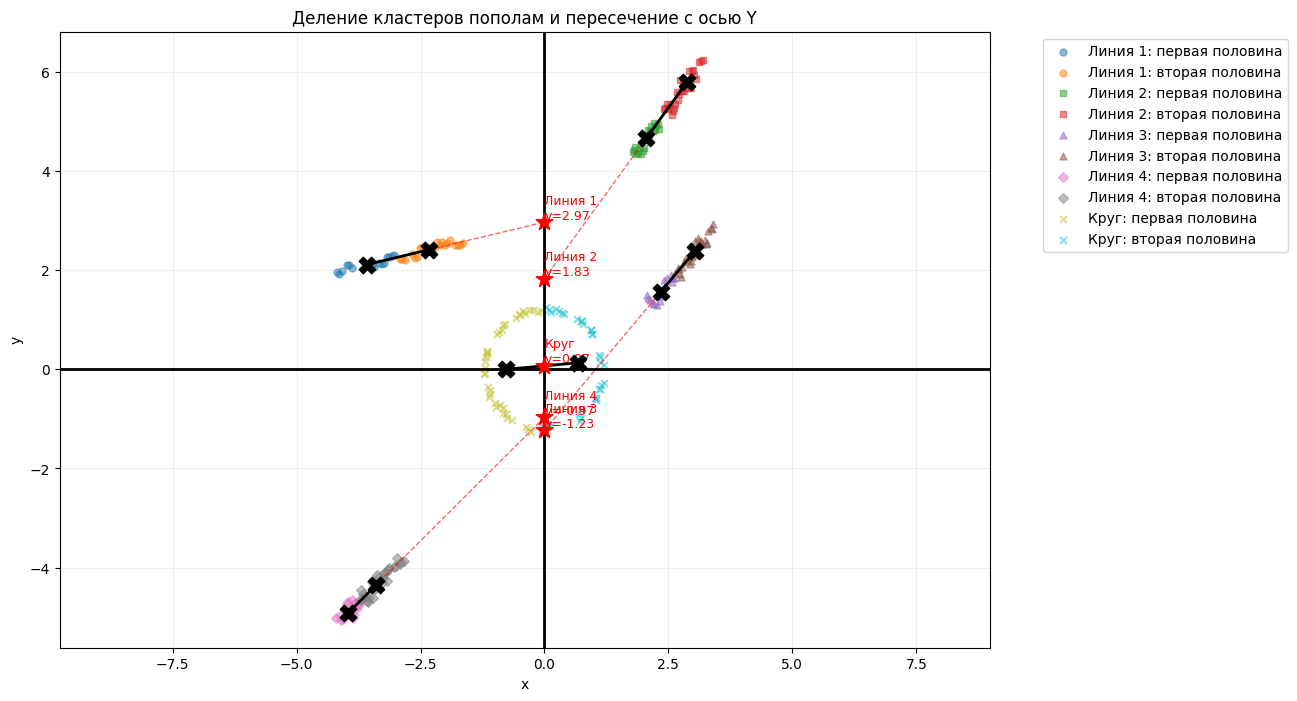

In [21]:
plt.figure(figsize=(12, 8))

plot_object_with_cluster_halves_y_intersection(
    points_1, labels_1, y_intersections_all, "Линия 1", marker="o"
)

plot_object_with_cluster_halves_y_intersection(
    points_2, labels_2, y_intersections_all, "Линия 2", marker="s"
)

plot_object_with_cluster_halves_y_intersection(
    points_3, labels_3, y_intersections_all, "Линия 3", marker="^"
)

plot_object_with_cluster_halves_y_intersection(
    points_4, labels_4, y_intersections_all, "Линия 4", marker="D"
)

plot_object_with_cluster_halves_y_intersection(
    points_c, labels_c, y_intersections_all, "Круг", marker="x"
)

# Оси
plt.axhline(0, color="black", linewidth=2)
plt.axvline(0, color="black", linewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Деление кластеров пополам и пересечение с осью Y")

plt.grid(alpha=0.2)
plt.axis("equal")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

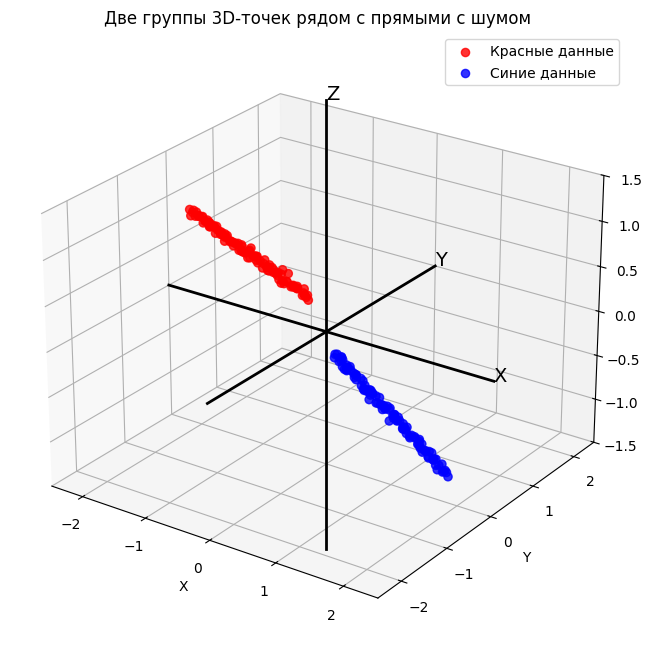

In [22]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


def make_noisy_3d_line(
    start_point,
    direction,
    n=80,
    t_min=-1.0,
    t_max=1.0,
    noise=0.03
):
    """
    Генерация точек вокруг 3D-прямой.

    Прямая задаётся как:
        point = start_point + t * direction

    Потом к каждой координате добавляется шум.
    """

    start_point = np.array(start_point, dtype=float)
    direction = np.array(direction, dtype=float)

    # Нормируем направление, чтобы масштаб был понятнее
    direction = direction / np.linalg.norm(direction)

    t = np.linspace(t_min, t_max, n)

    points = start_point + t[:, None] * direction

    # Добавляем шум по x, y, z
    points_noisy = points + rng.normal(0, noise, size=points.shape)

    return points_noisy


# ----------------------------
# Красная прямая
# ----------------------------
red_points = make_noisy_3d_line(
    start_point=[-1.5, 0.4, 0.45],
    direction=[1.0, -0.25, -0.15],
    n=100,
    t_min=-1.2,
    t_max=1.2,
    noise=0.025
)

# ----------------------------
# Синяя прямая
# ----------------------------
blue_points = make_noisy_3d_line(
    start_point=[1.3, -0.5, -0.45],
    direction=[1.0, -0.35, -0.25],
    n=100,
    t_min=-1.2,
    t_max=1.2,
    noise=0.025
)


# ----------------------------
# Отрисовка в 3D
# ----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Точки
ax.scatter(
    red_points[:, 0],
    red_points[:, 1],
    red_points[:, 2],
    color="red",
    s=35,
    alpha=0.8,
    label="Красные данные"
)

ax.scatter(
    blue_points[:, 0],
    blue_points[:, 1],
    blue_points[:, 2],
    color="blue",
    s=35,
    alpha=0.8,
    label="Синие данные"
)


# ----------------------------
# Нарисуем оси X, Y, Z
# ----------------------------
axis_len = 2.5

ax.plot([-axis_len, axis_len], [0, 0], [0, 0], color="black", linewidth=2)
ax.plot([0, 0], [-axis_len, axis_len], [0, 0], color="black", linewidth=2)
ax.plot([0, 0], [0, 0], [-axis_len, axis_len], color="black", linewidth=2)

ax.text(axis_len, 0, 0, "X", fontsize=14, color="black")
ax.text(0, axis_len, 0, "Y", fontsize=14, color="black")
ax.text(0, 0, axis_len, "Z", fontsize=14, color="black")


# ----------------------------
# Подписи и оформление
# ----------------------------
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Две группы 3D-точек рядом с прямыми с шумом")

ax.legend()

ax.grid(True)

# Чтобы масштаб по осям был более похожим
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_zlim(-1.5, 1.5)

# Угол камеры
ax.view_init(elev=25, azim=-55)

plt.show()

In [23]:
red_points[:5], blue_points[:5]

(array([[-2.64441894,  0.66200961,  0.64156681],
        [-2.60524928,  0.63341497,  0.58676002],
        [-2.60229391,  0.66846642,  0.61540346],
        [-2.60354255,  0.69253906,  0.63177727],
        [-2.55729221,  0.69291677,  0.62052918]]),
 array([[ 0.24082725, -0.15252176, -0.15281517],
        [ 0.21170019, -0.12350277, -0.20630079],
        [ 0.23382174, -0.09726299, -0.17097941],
        [ 0.30776077, -0.10812324, -0.18013608],
        [ 0.33032117, -0.13437815, -0.175981  ]]))

In [35]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor


def train_nn_y_from_xz(points, random_state=42):
    """
    Обучает нейросеть:
        входы: x, z
        выход: y

    Архитектура:
        2 -> 2 -> 1

    Модель:
        y = v1 * tanh(w11*x + w12*z + b1)
          + v2 * tanh(w21*x + w22*z + b2)
          + c
    """

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    X = np.column_stack([x, z])
    target = y

    model = MLPRegressor(
        hidden_layer_sizes=(2,),
        activation="tanh",
        solver="lbfgs",
        alpha=0.0,
        max_iter=10000,
        random_state=random_state
    )

    model.fit(X, target)

    return model

In [36]:
red_nn = train_nn_y_from_xz(red_points, random_state=40)
blue_nn = train_nn_y_from_xz(blue_points, random_state=40)

In [37]:
def nn_to_markdown_function(model, name):
    """
    Печатает обученную нейросеть в виде формулы Markdown.
    """

    # Веса вход -> hidden
    W1 = model.coefs_[0]        # shape: (2, 2)
    b1 = model.intercepts_[0]   # shape: (2,)

    # Веса hidden -> output
    W2 = model.coefs_[1]        # shape: (2, 1)
    b2 = model.intercepts_[1]   # shape: (1,)

    w11 = W1[0, 0]  # x -> h1
    w12 = W1[1, 0]  # z -> h1
    b_h1 = b1[0]

    w21 = W1[0, 1]  # x -> h2
    w22 = W1[1, 1]  # z -> h2
    b_h2 = b1[1]

    v1 = W2[0, 0]   # h1 -> y
    v2 = W2[1, 0]   # h2 -> y
    c = b2[0]

    markdown = f"""
## {name}

Нейросеть:

$$
\\hat y = v_1 \\cdot \\tanh(w_{{11}}x + w_{{12}}z + b_1)
        + v_2 \\cdot \\tanh(w_{{21}}x + w_{{22}}z + b_2)
        + c
$$

После обучения:

$$
\\hat y =
{v1:.6f} \\cdot \\tanh({w11:.6f}x + {w12:.6f}z + {b_h1:.6f})
+
{v2:.6f} \\cdot \\tanh({w21:.6f}x + {w22:.6f}z + {b_h2:.6f})
+
{c:.6f}
$$

Где:

$$
h_1 = \\tanh({w11:.6f}x + {w12:.6f}z + {b_h1:.6f})
$$

$$
h_2 = \\tanh({w21:.6f}x + {w22:.6f}z + {b_h2:.6f})
$$

$$
\\hat y = {v1:.6f}h_1 + {v2:.6f}h_2 + {c:.6f}
$$
"""

    return markdown

In [38]:
red_markdown = nn_to_markdown_function(red_nn, "Красная нейросеть")
blue_markdown = nn_to_markdown_function(blue_nn, "Синяя нейросеть")

print(red_markdown)
print(blue_markdown)


## Красная нейросеть

Нейросеть:

$$
\hat y = v_1 \cdot \tanh(w_{11}x + w_{12}z + b_1)
        + v_2 \cdot \tanh(w_{21}x + w_{22}z + b_2)
        + c
$$

После обучения:

$$
\hat y =
0.632027 \cdot \tanh(-0.139760x + 0.711235z + -0.227667)
+
0.504317 \cdot \tanh(-0.351424x + -0.464538z + -0.885180)
+
0.471488
$$

Где:

$$
h_1 = \tanh(-0.139760x + 0.711235z + -0.227667)
$$

$$
h_2 = \tanh(-0.351424x + -0.464538z + -0.885180)
$$

$$
\hat y = 0.632027h_1 + 0.504317h_2 + 0.471488
$$


## Синяя нейросеть

Нейросеть:

$$
\hat y = v_1 \cdot \tanh(w_{11}x + w_{12}z + b_1)
        + v_2 \cdot \tanh(w_{21}x + w_{22}z + b_2)
        + c
$$

После обучения:

$$
\hat y =
1.022598 \cdot \tanh(-0.138743x + 0.657091z + 0.253356)
+
0.784562 \cdot \tanh(-0.280138x + -0.721560z + -0.486463)
+
0.089558
$$

Где:

$$
h_1 = \tanh(-0.138743x + 0.657091z + 0.253356)
$$

$$
h_2 = \tanh(-0.280138x + -0.721560z + -0.486463)
$$

$$
\hat y = 1.022598h_1 + 0.784562h_2 + 0.089558
$$




## Красная нейросеть

Нейросеть:

$$
\hat y = v_1 \cdot \tanh(w_{11}x + w_{12}z + b_1)
        + v_2 \cdot \tanh(w_{21}x + w_{22}z + b_2)
        + c
$$

После обучения:

$$
\hat y =
0.632027 \cdot \tanh(-0.139760x + 0.711235z + -0.227667)
+
0.504317 \cdot \tanh(-0.351424x + -0.464538z + -0.885180)
+
0.471488
$$

Где:

$$
h_1 = \tanh(-0.139760x + 0.711235z + -0.227667)
$$

$$
h_2 = \tanh(-0.351424x + -0.464538z + -0.885180)
$$

$$
\hat y = 0.632027h_1 + 0.504317h_2 + 0.471488
$$


## Синяя нейросеть

Нейросеть:

$$
\hat y = v_1 \cdot \tanh(w_{11}x + w_{12}z + b_1)
        + v_2 \cdot \tanh(w_{21}x + w_{22}z + b_2)
        + c
$$

После обучения:

$$
\hat y =
1.022598 \cdot \tanh(-0.138743x + 0.657091z + 0.253356)
+
0.784562 \cdot \tanh(-0.280138x + -0.721560z + -0.486463)
+
0.089558
$$

Где:

$$
h_1 = \tanh(-0.138743x + 0.657091z + 0.253356)
$$

$$
h_2 = \tanh(-0.280138x + -0.721560z + -0.486463)
$$

$$
\hat y = 1.022598h_1 + 0.784562h_2 + 0.089558
$$


In [39]:
def predict_nn_y(model, x, z):
    X = np.column_stack([x, z])
    return model.predict(X)

In [40]:
red_pred_y = predict_nn_y(
    red_nn,
    red_points[:, 0],
    red_points[:, 2]
)

blue_pred_y = predict_nn_y(
    blue_nn,
    blue_points[:, 0],
    blue_points[:, 2]
)

In [41]:
from matplotlib import pyplot as plt


def make_nn_surface(points, model, n=40):
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    z_min, z_max = points[:, 2].min(), points[:, 2].max()

    x_grid = np.linspace(x_min, x_max, n)
    z_grid = np.linspace(z_min, z_max, n)

    X_grid, Z_grid = np.meshgrid(x_grid, z_grid)

    features = np.column_stack([
        X_grid.ravel(),
        Z_grid.ravel()
    ])

    Y_pred = model.predict(features).reshape(X_grid.shape)

    return X_grid, Y_pred, Z_grid

In [42]:
red_X_grid, red_Y_grid, red_Z_grid = make_nn_surface(red_points, red_nn)
blue_X_grid, blue_Y_grid, blue_Z_grid = make_nn_surface(blue_points, blue_nn)

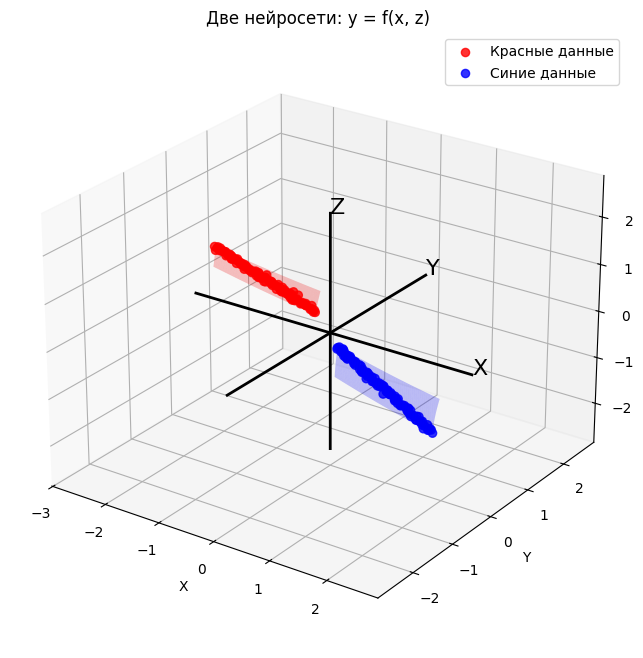

In [43]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Красные точки
ax.scatter(
    red_points[:, 0],
    red_points[:, 1],
    red_points[:, 2],
    color="red",
    s=35,
    alpha=0.8,
    label="Красные данные"
)

# Синие точки
ax.scatter(
    blue_points[:, 0],
    blue_points[:, 1],
    blue_points[:, 2],
    color="blue",
    s=35,
    alpha=0.8,
    label="Синие данные"
)

# Поверхность красной нейросети
ax.plot_surface(
    red_X_grid,
    red_Y_grid,
    red_Z_grid,
    color="red",
    alpha=0.25
)

# Поверхность синей нейросети
ax.plot_surface(
    blue_X_grid,
    blue_Y_grid,
    blue_Z_grid,
    color="blue",
    alpha=0.25
)

# Оси X, Y, Z
axis_len = 2.5

ax.plot(
    [-axis_len, axis_len],
    [0, 0],
    [0, 0],
    color="black",
    linewidth=2
)

ax.plot(
    [0, 0],
    [-axis_len, axis_len],
    [0, 0],
    color="black",
    linewidth=2
)

ax.plot(
    [0, 0],
    [0, 0],
    [-axis_len, axis_len],
    color="black",
    linewidth=2
)

# Подписи осей
ax.text(axis_len, 0, 0, "X", fontsize=16, color="black")
ax.text(0, axis_len, 0, "Y", fontsize=16, color="black")
ax.text(0, 0, axis_len, "Z", fontsize=16, color="black")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Две нейросети: y = f(x, z)")

ax.legend()
ax.view_init(elev=25, azim=-55)

plt.show()

### Главная проблема как понять какой вес w11 красной нейросети соответствует какому весу синий нейросети?

In [45]:
# Объединяем красные и синие точки
all_points = np.vstack([
    red_points,
    blue_points
])

# Метки, чтобы понимать, откуда точка
point_group = np.array(
    ["red"] * len(red_points) + ["blue"] * len(blue_points)
)

x = all_points[:, 0]
y = all_points[:, 1]
z = all_points[:, 2]

In [48]:
import numpy as np


# ============================
# Красная tanh-нейросеть
# ============================

def red_nn_h1(x, z):
    return np.tanh(
        (-0.139760) * x
        + 0.711235 * z
        + (-0.227667)
    )


def red_nn_h2(x, z):
    return np.tanh(
        (-0.351424) * x
        + (-0.464538) * z
        + (-0.885180)
    )


def red_nn_predict(x, z):
    h1 = red_nn_h1(x, z)
    h2 = red_nn_h2(x, z)

    y_hat = (
        0.632027 * h1
        + 0.504317 * h2
        + 0.471488
    )

    return y_hat


# ============================
# Синяя tanh-нейросеть
# ============================

def blue_nn_h1(x, z):
    return np.tanh(
        (-0.138743) * x
        + 0.657091 * z
        + 0.253356
    )


def blue_nn_h2(x, z):
    return np.tanh(
        (-0.280138) * x
        + (-0.721560) * z
        + (-0.486463)
    )


def blue_nn_predict(x, z):
    h1 = blue_nn_h1(x, z)
    h2 = blue_nn_h2(x, z)

    y_hat = (
        1.022598 * h1
        + 0.784562 * h2
        + 0.089558
    )

    return y_hat

In [49]:
red_h1, red_h2 = red_nn_h1(x, z), red_nn_h2(x, z)
blue_h1, blue_h2 = blue_nn_h1(x, z), blue_nn_h2(x, z)

In [50]:
hidden_df = pd.DataFrame({
    "group": point_group,

    "x": x,
    "y": y,
    "z": z,

    "red_nn_h1": red_h1,
    "red_nn_h2": red_h2,

    "blue_nn_h1": blue_h1,
    "blue_nn_h2": blue_h2,
})

hidden_df.head()

,group,x,y,z,red_nn_h1,red_nn_h2,blue_nn_h1,blue_nn_h2
0,red,-2.644419,0.662010,0.641567,0.535783,-0.248581,0.778605,-0.205616
1,red,-2.605249,0.633415,0.586760,0.503338,-0.237578,0.761750,-0.178097
2,red,-2.602294,0.668466,0.615403,0.518090,-0.251066,0.769370,-0.198828
3,red,-2.603543,0.692539,0.631777,0.526685,-0.257769,0.773794,-0.209814
4,red,-2.557292,0.692917,0.620529,0.516154,-0.268035,0.768194,-0.214437


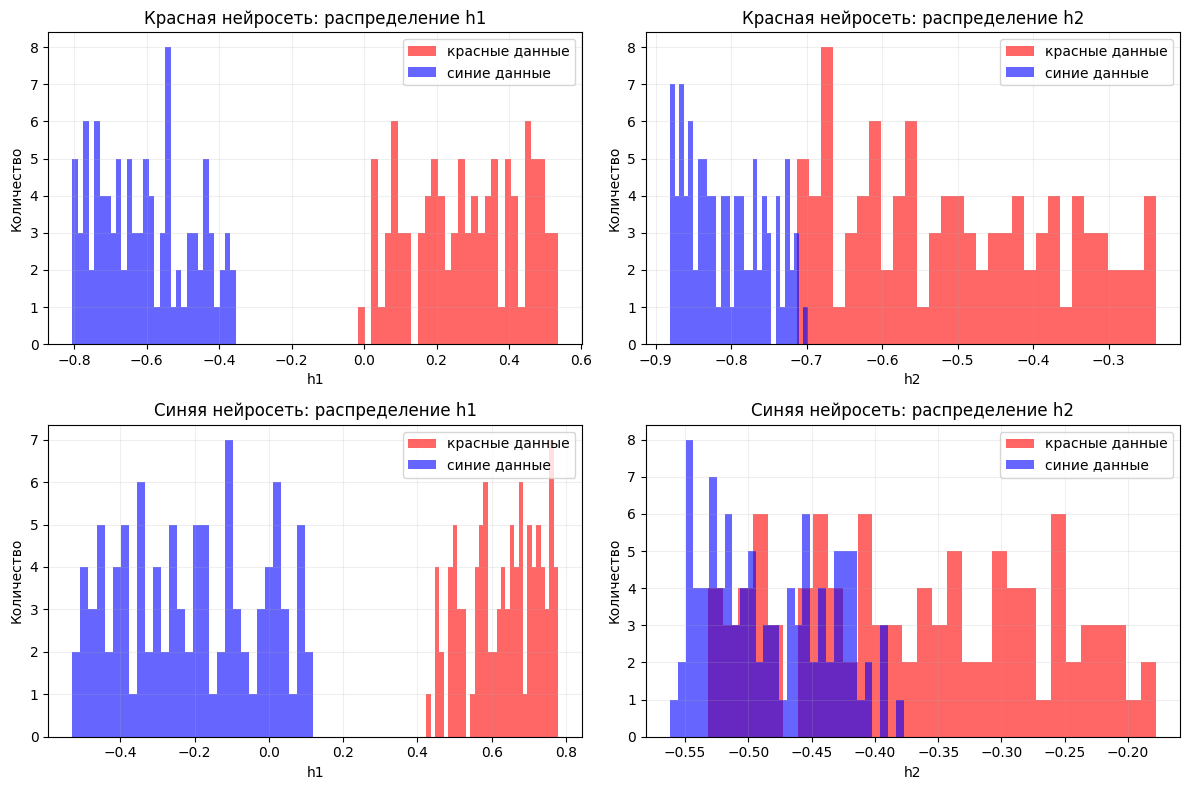

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ----------------------------
# Красная нейросеть: h1
# ----------------------------
axes[0, 0].hist(
    hidden_df.loc[hidden_df["group"] == "red", "red_nn_h1"],
    bins=30,
    alpha=0.6,
    color="red",
    label="красные данные"
)

axes[0, 0].hist(
    hidden_df.loc[hidden_df["group"] == "blue", "red_nn_h1"],
    bins=30,
    alpha=0.6,
    color="blue",
    label="синие данные"
)

axes[0, 0].set_title("Красная нейросеть: распределение h1")
axes[0, 0].set_xlabel("h1")
axes[0, 0].set_ylabel("Количество")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.2)


# ----------------------------
# Красная нейросеть: h2
# ----------------------------
axes[0, 1].hist(
    hidden_df.loc[hidden_df["group"] == "red", "red_nn_h2"],
    bins=30,
    alpha=0.6,
    color="red",
    label="красные данные"
)

axes[0, 1].hist(
    hidden_df.loc[hidden_df["group"] == "blue", "red_nn_h2"],
    bins=30,
    alpha=0.6,
    color="blue",
    label="синие данные"
)

axes[0, 1].set_title("Красная нейросеть: распределение h2")
axes[0, 1].set_xlabel("h2")
axes[0, 1].set_ylabel("Количество")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.2)


# ----------------------------
# Синяя нейросеть: h1
# ----------------------------
axes[1, 0].hist(
    hidden_df.loc[hidden_df["group"] == "red", "blue_nn_h1"],
    bins=30,
    alpha=0.6,
    color="red",
    label="красные данные"
)

axes[1, 0].hist(
    hidden_df.loc[hidden_df["group"] == "blue", "blue_nn_h1"],
    bins=30,
    alpha=0.6,
    color="blue",
    label="синие данные"
)

axes[1, 0].set_title("Синяя нейросеть: распределение h1")
axes[1, 0].set_xlabel("h1")
axes[1, 0].set_ylabel("Количество")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.2)


# ----------------------------
# Синяя нейросеть: h2
# ----------------------------
axes[1, 1].hist(
    hidden_df.loc[hidden_df["group"] == "red", "blue_nn_h2"],
    bins=30,
    alpha=0.6,
    color="red",
    label="красные данные"
)

axes[1, 1].hist(
    hidden_df.loc[hidden_df["group"] == "blue", "blue_nn_h2"],
    bins=30,
    alpha=0.6,
    color="blue",
    label="синие данные"
)

axes[1, 1].set_title("Синяя нейросеть: распределение h2")
axes[1, 1].set_xlabel("h2")
axes[1, 1].set_ylabel("Количество")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

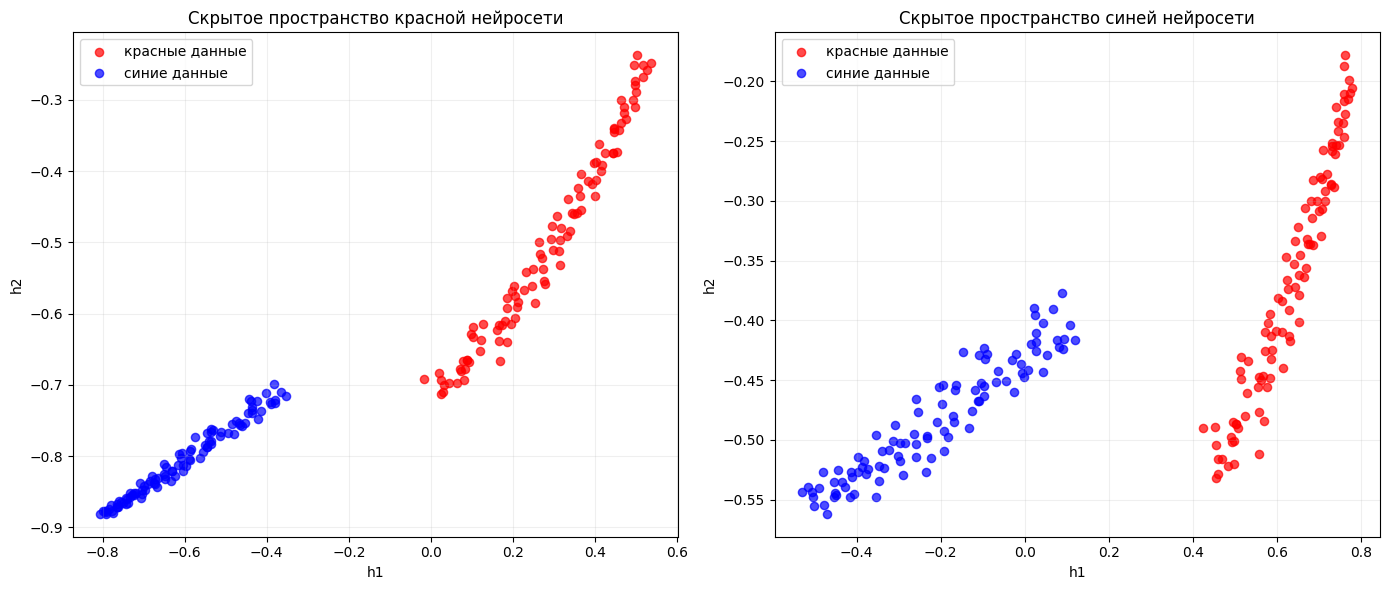

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Красная нейросеть
axes[0].scatter(
    hidden_df.loc[hidden_df["group"] == "red", "red_nn_h1"],
    hidden_df.loc[hidden_df["group"] == "red", "red_nn_h2"],
    color="red",
    alpha=0.7,
    s=35,
    label="красные данные"
)

axes[0].scatter(
    hidden_df.loc[hidden_df["group"] == "blue", "red_nn_h1"],
    hidden_df.loc[hidden_df["group"] == "blue", "red_nn_h2"],
    color="blue",
    alpha=0.7,
    s=35,
    label="синие данные"
)

axes[0].set_xlabel("h1")
axes[0].set_ylabel("h2")
axes[0].set_title("Скрытое пространство красной нейросети")
axes[0].grid(alpha=0.2)
axes[0].legend()


# Синяя нейросеть
axes[1].scatter(
    hidden_df.loc[hidden_df["group"] == "red", "blue_nn_h1"],
    hidden_df.loc[hidden_df["group"] == "red", "blue_nn_h2"],
    color="red",
    alpha=0.7,
    s=35,
    label="красные данные"
)

axes[1].scatter(
    hidden_df.loc[hidden_df["group"] == "blue", "blue_nn_h1"],
    hidden_df.loc[hidden_df["group"] == "blue", "blue_nn_h2"],
    color="blue",
    alpha=0.7,
    s=35,
    label="синие данные"
)

axes[1].set_xlabel("h1")
axes[1].set_ylabel("h2")
axes[1].set_title("Скрытое пространство синей нейросети")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
from scipy.stats import chi2_contingency

In [54]:
def minmax_scale(values):
    values = np.asarray(values)

    v_min = values.min()
    v_max = values.max()

    if np.isclose(v_max, v_min):
        return np.zeros_like(values)

    return (values - v_min) / (v_max - v_min)

In [55]:
def chi_square_compare_scaled(values_a, values_b, bins=20):
    """
    1. Отдельно приводит values_a и values_b к [0, 1]
    2. Строит гистограммы
    3. Удаляет полностью пустые бины
    4. Сравнивает через chi-square
    """

    values_a_scaled = minmax_scale(values_a)
    values_b_scaled = minmax_scale(values_b)

    hist_a, bin_edges = np.histogram(
        values_a_scaled,
        bins=bins,
        range=(0, 1)
    )

    hist_b, _ = np.histogram(
        values_b_scaled,
        bins=bin_edges
    )

    # Удаляем бины, где обе частоты равны 0
    non_empty_bins = (hist_a + hist_b) > 0

    hist_a_clean = hist_a[non_empty_bins]
    hist_b_clean = hist_b[non_empty_bins]

    if len(hist_a_clean) < 2:
        return {
            "chi2": np.nan,
            "p_value": np.nan,
            "dof": np.nan,
            "hist_a": hist_a,
            "hist_b": hist_b,
            "hist_a_scaled": hist_a_clean,
            "hist_b_scaled": hist_b_clean,
            "bin_edges": bin_edges,
            "n_bins_used": len(hist_a_clean),
        }

    contingency_table = np.vstack([
        hist_a_clean,
        hist_b_clean
    ])

    chi2_stat, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    return {
        "chi2": chi2_stat,
        "p_value": p_value,
        "dof": dof,
        "hist_a": hist_a,
        "hist_b": hist_b,
        "hist_a_clean": hist_a_clean,
        "hist_b_clean": hist_b_clean,
        "expected": expected,
        "bin_edges": bin_edges,
        "n_bins_used": len(hist_a_clean),
        "values_a_scaled": values_a_scaled,
        "values_b_scaled": values_b_scaled,
    }

In [56]:
comparisons = [
    ("red_h1_vs_blue_h1", "red_nn_h1", "blue_nn_h1"),
    ("red_h1_vs_blue_h2", "red_nn_h1", "blue_nn_h2"),
    ("red_h2_vs_blue_h1", "red_nn_h2", "blue_nn_h1"),
    ("red_h2_vs_blue_h2", "red_nn_h2", "blue_nn_h2"),
]

In [57]:
results = []

scaled_comparison_data = {}

for comparison_name, col_a, col_b in comparisons:
    values_a = hidden_df[col_a].values
    values_b = hidden_df[col_b].values

    result = chi_square_compare_scaled(
        values_a,
        values_b,
        bins=20
    )

    results.append({
        "comparison": comparison_name,
        "left": col_a,
        "right": col_b,
        "chi2": result["chi2"],
        "p_value": result["p_value"],
        "dof": result["dof"],
        "n_left": len(values_a),
        "n_right": len(values_b),
        "n_bins_used": result["n_bins_used"],
    })

    scaled_comparison_data[comparison_name] = result

chi_square_scaled_results = pd.DataFrame(results)

chi_square_scaled_results

,comparison,left,right,chi2,p_value,dof,n_left,n_right,n_bins_used
0,red_h1_vs_blue_h1,red_nn_h1,blue_nn_h1,73.993460,9.426000e-09,18,200,200,19
1,red_h1_vs_blue_h2,red_nn_h1,blue_nn_h2,82.014738,8.338322e-10,19,200,200,20
2,red_h2_vs_blue_h1,red_nn_h2,blue_nn_h1,87.309700,9.905155e-11,19,200,200,20
3,red_h2_vs_blue_h2,red_nn_h2,blue_nn_h2,23.539662,2.144067e-01,19,200,200,20


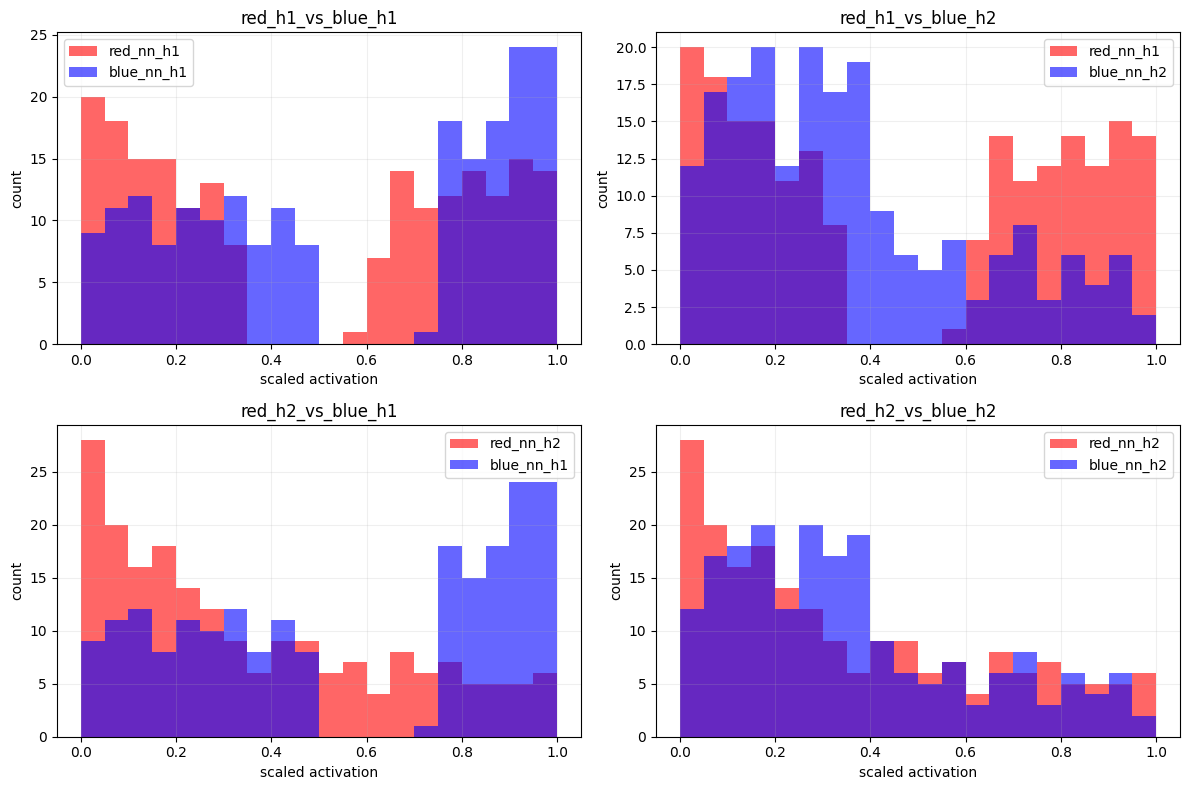

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.ravel()

for ax, (comparison_name, col_a, col_b) in zip(axes, comparisons):
    values_a = hidden_df[col_a].values
    values_b = hidden_df[col_b].values

    values_a_scaled = minmax_scale(values_a)
    values_b_scaled = minmax_scale(values_b)

    ax.hist(
        values_a_scaled,
        bins=20,
        range=(0, 1),
        alpha=0.6,
        color="red",
        label=col_a
    )

    ax.hist(
        values_b_scaled,
        bins=20,
        range=(0, 1),
        alpha=0.6,
        color="blue",
        label=col_b
    )

    ax.set_title(comparison_name)
    ax.set_xlabel("scaled activation")
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()

### Обучение объедененной нейросети

In [61]:
import numpy as np
from sklearn.neural_network import MLPRegressor


# Объединяем данные
all_points = np.vstack([
    red_points,
    blue_points
])

# Входы: x, z
X_all = np.column_stack([
    all_points[:, 0],  # x
    all_points[:, 2],  # z
])

# Цель: y
y_all = all_points[:, 1]


# Такая же нейросеть: 2 входа -> 2 hidden -> 1 выход
combined_nn = MLPRegressor(
    hidden_layer_sizes=(2,),
    activation="tanh",
    solver="lbfgs",
    alpha=0.0,
    max_iter=10000,
    random_state=40
)

combined_nn.fit(X_all, y_all)

,loss,'squared_error'
,hidden_layer_sizes,"(2,)"
,activation,'tanh'
,solver,'lbfgs'
,alpha,0.0
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,10000
,shuffle,True


In [62]:
def nn_to_markdown_function(model, name):
    W1 = model.coefs_[0]
    b1 = model.intercepts_[0]

    W2 = model.coefs_[1]
    b2 = model.intercepts_[1]

    w11 = W1[0, 0]
    w12 = W1[1, 0]
    b_h1 = b1[0]

    w21 = W1[0, 1]
    w22 = W1[1, 1]
    b_h2 = b1[1]

    v1 = W2[0, 0]
    v2 = W2[1, 0]
    c = b2[0]

    markdown = f"""
## {name}

$$
\\hat y =
{v1:.6f} \\cdot \\tanh({w11:.6f}x + {w12:.6f}z + {b_h1:.6f})
+
{v2:.6f} \\cdot \\tanh({w21:.6f}x + {w22:.6f}z + {b_h2:.6f})
+
{c:.6f}
$$

Где:

$$
h_1 = \\tanh({w11:.6f}x + {w12:.6f}z + {b_h1:.6f})
$$

$$
h_2 = \\tanh({w21:.6f}x + {w22:.6f}z + {b_h2:.6f})
$$

$$
\\hat y = {v1:.6f}h_1 + {v2:.6f}h_2 + {c:.6f}
$$
"""

    return markdown

In [63]:
print(nn_to_markdown_function(combined_nn, "Нейросеть, обученная на объединённых данных"))


## Нейросеть, обученная на объединённых данных

$$
\hat y =
1.362886 \cdot \tanh(-0.096306x + 0.499058z + 0.295191)
+
0.654166 \cdot \tanh(-0.258195x + -0.717978z + 0.207361)
+
-0.556816
$$

Где:

$$
h_1 = \tanh(-0.096306x + 0.499058z + 0.295191)
$$

$$
h_2 = \tanh(-0.258195x + -0.717978z + 0.207361)
$$

$$
\hat y = 1.362886h_1 + 0.654166h_2 + -0.556816
$$




## Нейросеть, обученная на объединённых данных

$$
\hat y =
1.362886 \cdot \tanh(-0.096306x + 0.499058z + 0.295191)
+
0.654166 \cdot \tanh(-0.258195x + -0.717978z + 0.207361)
+
-0.556816
$$

Где:

$$
h_1 = \tanh(-0.096306x + 0.499058z + 0.295191)
$$

$$
h_2 = \tanh(-0.258195x + -0.717978z + 0.207361)
$$

$$
\hat y = 1.362886h_1 + 0.654166h_2 + -0.556816
$$


In [64]:
import numpy as np


# ============================
# Усреднённая tanh-нейросеть
# ============================

def averaged_nn_h1(x, z):
    return np.tanh(
        (-0.139252) * x
        + 0.684163 * z
        + 0.012845
    )


def averaged_nn_h2(x, z):
    return np.tanh(
        (-0.315781) * x
        + (-0.593049) * z
        + (-0.685822)
    )


def averaged_nn_predict(x, z):
    h1 = averaged_nn_h1(x, z)
    h2 = averaged_nn_h2(x, z)

    y_hat = (
        0.827313 * h1
        + 0.644440 * h2
        + 0.280523
    )

    return y_hat

## Усреднённая нейросеть

Нейросеть:

$$
\hat y =
v_1 \cdot \tanh(w_{11}x + w_{12}z + b_1)
+
v_2 \cdot \tanh(w_{21}x + w_{22}z + b_2)
+
c
$$

После усреднения:

$$
\hat y =
0.827313 \cdot \tanh(-0.139252x + 0.684163z + 0.012845)
+
0.644440 \cdot \tanh(-0.315781x - 0.593049z - 0.685822)
+
0.280523
$$

Где:

$$
h_1 =
\tanh(-0.139252x + 0.684163z + 0.012845)
$$

$$
h_2 =
\tanh(-0.315781x - 0.593049z - 0.685822)
$$

$$
\hat y =
0.827313h_1
+
0.644440h_2
+
0.280523
$$


## Нейросеть, обученная на объединённых данных

$$
\hat y =
1.362886 \cdot \tanh(-0.096306x + 0.499058z + 0.295191)
+
0.654166 \cdot \tanh(-0.258195x + -0.717978z + 0.207361)
+
-0.556816
$$

Где:

$$
h_1 = \tanh(-0.096306x + 0.499058z + 0.295191)
$$

$$
h_2 = \tanh(-0.258195x + -0.717978z + 0.207361)
$$

$$
\hat y = 1.362886h_1 + 0.654166h_2 + -0.556816
$$


In [66]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib import pyplot as plt

In [67]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    }

In [68]:
# Красные данные
x_red = red_points[:, 0]
y_red = red_points[:, 1]
z_red = red_points[:, 2]

# Синие данные
x_blue = blue_points[:, 0]
y_blue = blue_points[:, 1]
z_blue = blue_points[:, 2]

In [69]:
# 1. Красная модель на красных данных
y_pred_red_model_on_red = red_nn_predict(x_red, z_red)

# 2. Синяя модель на синих данных
y_pred_blue_model_on_blue = blue_nn_predict(x_blue, z_blue)

# 3. Объединённая модель на красных данных
X_red = np.column_stack([x_red, z_red])
y_pred_combined_on_red = combined_nn.predict(X_red)

# 4. Объединённая модель на синих данных
X_blue = np.column_stack([x_blue, z_blue])
y_pred_combined_on_blue = combined_nn.predict(X_blue)

# 5. Усреднённая модель на красных данных
y_pred_avg_on_red = averaged_nn_predict(x_red, z_red)

# 6. Усреднённая модель на синих данных
y_pred_avg_on_blue = averaged_nn_predict(x_blue, z_blue)

In [70]:
metrics_rows = []

# Красная модель
metrics_rows.append({
    "model": "Красная модель",
    "dataset": "Красные данные",
    **calc_metrics(y_red, y_pred_red_model_on_red)
})

# Синяя модель
metrics_rows.append({
    "model": "Синяя модель",
    "dataset": "Синие данные",
    **calc_metrics(y_blue, y_pred_blue_model_on_blue)
})

# Объединённая модель на красных
metrics_rows.append({
    "model": "Объединённая модель",
    "dataset": "Красные данные",
    **calc_metrics(y_red, y_pred_combined_on_red)
})

# Объединённая модель на синих
metrics_rows.append({
    "model": "Объединённая модель",
    "dataset": "Синие данные",
    **calc_metrics(y_blue, y_pred_combined_on_blue)
})

# Усреднённая модель на красных
metrics_rows.append({
    "model": "Усреднённая модель",
    "dataset": "Красные данные",
    **calc_metrics(y_red, y_pred_avg_on_red)
})

# Усреднённая модель на синих
metrics_rows.append({
    "model": "Усреднённая модель",
    "dataset": "Синие данные",
    **calc_metrics(y_blue, y_pred_avg_on_blue)
})

metrics_df = pd.DataFrame(metrics_rows)

metrics_df

,model,dataset,MAE,MSE,RMSE,R2
0,Красная модель,Красные данные,0.019141,0.000605,0.024601,0.978276
1,Синяя модель,Синие данные,0.021153,0.000690,0.026259,0.986513
2,Объединённая модель,Красные данные,0.021851,0.000705,0.026549,0.974700
3,Объединённая модель,Синие данные,0.021774,0.000708,0.026615,0.986145
4,Усреднённая модель,Красные данные,0.023145,0.000949,0.030808,0.965932
5,Усреднённая модель,Синие данные,0.052338,0.003870,0.062212,0.924298


In [71]:
mae_pivot = metrics_df.pivot(
    index="model",
    columns="dataset",
    values="MAE"
)

mae_pivot

dataset,Красные данные,Синие данные
model,,
Красная модель,0.019141,NaN
Объединённая модель,0.021851,0.021774
Синяя модель,NaN,0.021153
Усреднённая модель,0.023145,0.052338


<Figure size 1000x600 with 0 Axes>

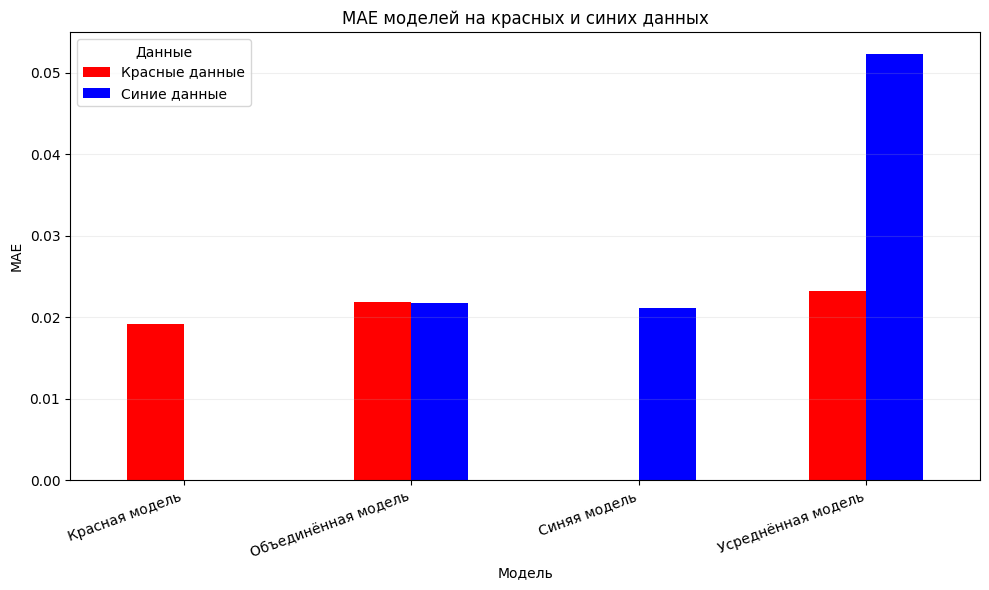

In [72]:
plt.figure(figsize=(10, 6))

mae_pivot.plot(
    kind="bar",
    figsize=(10, 6),
    color={
        "Красные данные": "red",
        "Синие данные": "blue"
    }
)

plt.ylabel("MAE")
plt.xlabel("Модель")
plt.title("MAE моделей на красных и синих данных")
plt.grid(axis="y", alpha=0.2)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Данные")
plt.tight_layout()
plt.show()

In [73]:
metrics_df.sort_values(["dataset", "MAE"])

,model,dataset,MAE,MSE,RMSE,R2
0,Красная модель,Красные данные,0.019141,0.000605,0.024601,0.978276
2,Объединённая модель,Красные данные,0.021851,0.000705,0.026549,0.974700
4,Усреднённая модель,Красные данные,0.023145,0.000949,0.030808,0.965932
1,Синяя модель,Синие данные,0.021153,0.000690,0.026259,0.986513
3,Объединённая модель,Синие данные,0.021774,0.000708,0.026615,0.986145
5,Усреднённая модель,Синие данные,0.052338,0.003870,0.062212,0.924298


In [74]:
def make_surface_for_function(x_min, x_max, z_min, z_max, predict_func, n=40):
    x_grid = np.linspace(x_min, x_max, n)
    z_grid = np.linspace(z_min, z_max, n)

    X_grid, Z_grid = np.meshgrid(x_grid, z_grid)

    Y_grid = predict_func(
        X_grid.ravel(),
        Z_grid.ravel()
    ).reshape(X_grid.shape)

    return X_grid, Y_grid, Z_grid

In [75]:
def combined_nn_predict_func(x, z):
    X = np.column_stack([x, z])
    return combined_nn.predict(X)

In [76]:
all_points = np.vstack([red_points, blue_points])

x_min, x_max = all_points[:, 0].min(), all_points[:, 0].max()
z_min, z_max = all_points[:, 2].min(), all_points[:, 2].max()

# Немного расширим границы
x_pad = 0.2 * (x_max - x_min)
z_pad = 0.2 * (z_max - z_min)

x_min -= x_pad
x_max += x_pad
z_min -= z_pad
z_max += z_pad

In [77]:
red_X, red_Y, red_Z = make_surface_for_function(
    x_min, x_max,
    z_min, z_max,
    red_nn_predict,
    n=40
)

blue_X, blue_Y, blue_Z = make_surface_for_function(
    x_min, x_max,
    z_min, z_max,
    blue_nn_predict,
    n=40
)

combined_X, combined_Y, combined_Z = make_surface_for_function(
    x_min, x_max,
    z_min, z_max,
    combined_nn_predict_func,
    n=40
)

avg_X, avg_Y, avg_Z = make_surface_for_function(
    x_min, x_max,
    z_min, z_max,
    averaged_nn_predict,
    n=40
)

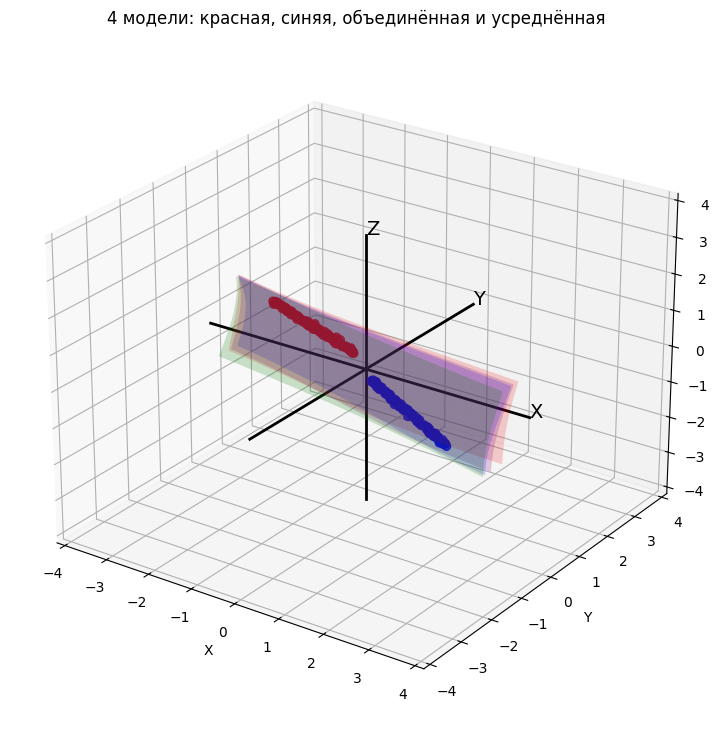

In [78]:
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")

# Исходные красные точки
ax.scatter(
    red_points[:, 0],
    red_points[:, 1],
    red_points[:, 2],
    color="red",
    s=35,
    alpha=0.8,
    label="Красные данные"
)

# Исходные синие точки
ax.scatter(
    blue_points[:, 0],
    blue_points[:, 1],
    blue_points[:, 2],
    color="blue",
    s=35,
    alpha=0.8,
    label="Синие данные"
)

# Красная модель
ax.plot_surface(
    red_X,
    red_Y,
    red_Z,
    color="red",
    alpha=0.18,
    linewidth=0,
    label="Красная модель"
)

# Синяя модель
ax.plot_surface(
    blue_X,
    blue_Y,
    blue_Z,
    color="blue",
    alpha=0.18,
    linewidth=0,
    label="Синяя модель"
)

# Объединённая модель
ax.plot_surface(
    combined_X,
    combined_Y,
    combined_Z,
    color="green",
    alpha=0.20,
    linewidth=0,
    label="Объединённая модель"
)

# Усреднённая модель
ax.plot_surface(
    avg_X,
    avg_Y,
    avg_Z,
    color="purple",
    alpha=0.20,
    linewidth=0,
    label="Усреднённая модель"
)

# Оси
axis_len = max(
    abs(x_min), abs(x_max),
    abs(z_min), abs(z_max),
    abs(all_points[:, 1].min()),
    abs(all_points[:, 1].max())
)

ax.plot(
    [-axis_len, axis_len],
    [0, 0],
    [0, 0],
    color="black",
    linewidth=2
)

ax.plot(
    [0, 0],
    [-axis_len, axis_len],
    [0, 0],
    color="black",
    linewidth=2
)

ax.plot(
    [0, 0],
    [0, 0],
    [-axis_len, axis_len],
    color="black",
    linewidth=2
)

ax.text(axis_len, 0, 0, "X", fontsize=14, color="black")
ax.text(0, axis_len, 0, "Y", fontsize=14, color="black")
ax.text(0, 0, axis_len, "Z", fontsize=14, color="black")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("4 модели: красная, синяя, объединённая и усреднённая")

ax.view_init(elev=25, azim=-55)

plt.show()

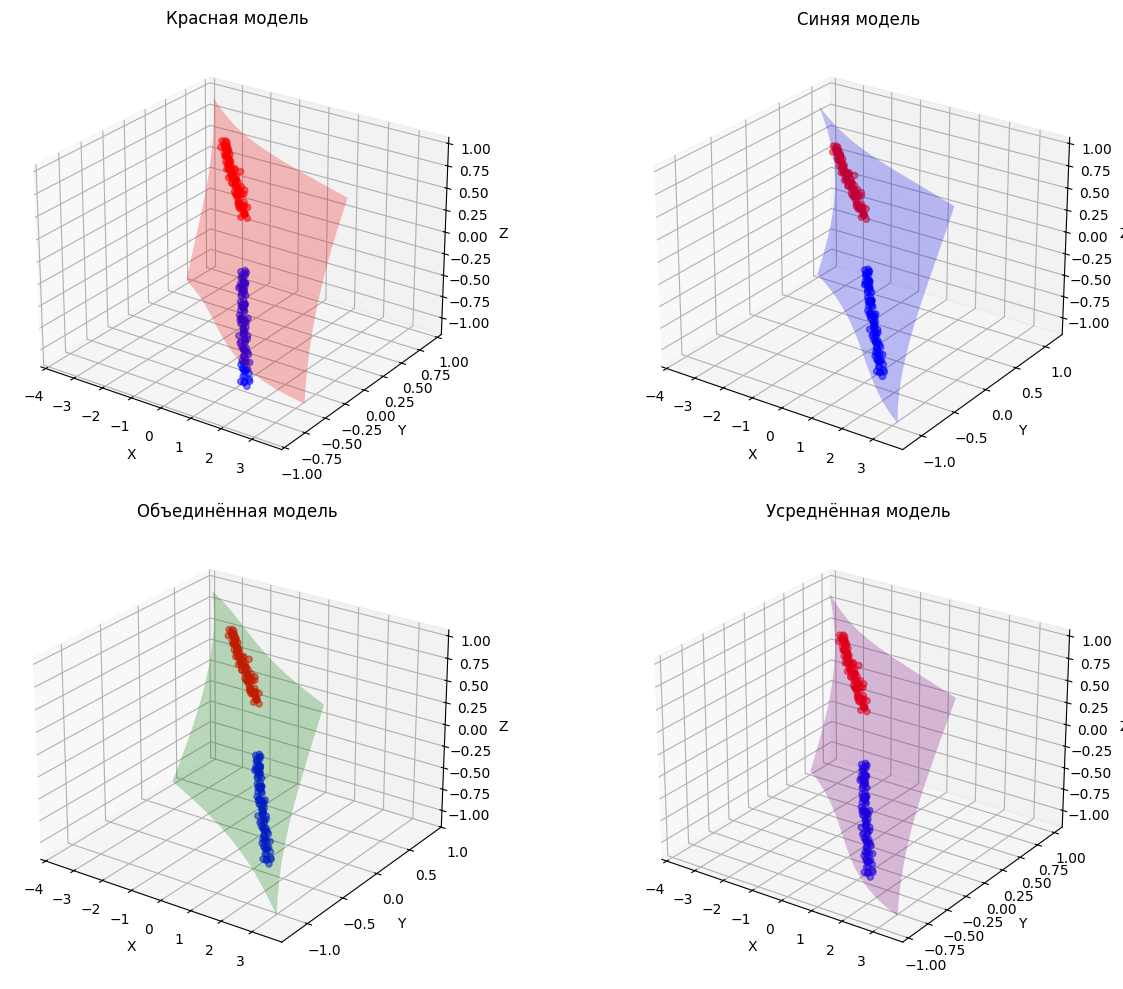

In [79]:
models_to_plot = [
    ("Красная модель", red_nn_predict, "red"),
    ("Синяя модель", blue_nn_predict, "blue"),
    ("Объединённая модель", combined_nn_predict_func, "green"),
    ("Усреднённая модель", averaged_nn_predict, "purple"),
]

fig = plt.figure(figsize=(14, 10))

for idx, (model_name, predict_func, color) in enumerate(models_to_plot, start=1):
    ax = fig.add_subplot(2, 2, idx, projection="3d")

    X_s, Y_s, Z_s = make_surface_for_function(
        x_min, x_max,
        z_min, z_max,
        predict_func,
        n=40
    )

    ax.scatter(
        red_points[:, 0],
        red_points[:, 1],
        red_points[:, 2],
        color="red",
        s=20,
        alpha=0.5
    )

    ax.scatter(
        blue_points[:, 0],
        blue_points[:, 1],
        blue_points[:, 2],
        color="blue",
        s=20,
        alpha=0.5
    )

    ax.plot_surface(
        X_s,
        Y_s,
        Z_s,
        color=color,
        alpha=0.25,
        linewidth=0
    )

    ax.set_title(model_name)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.show()

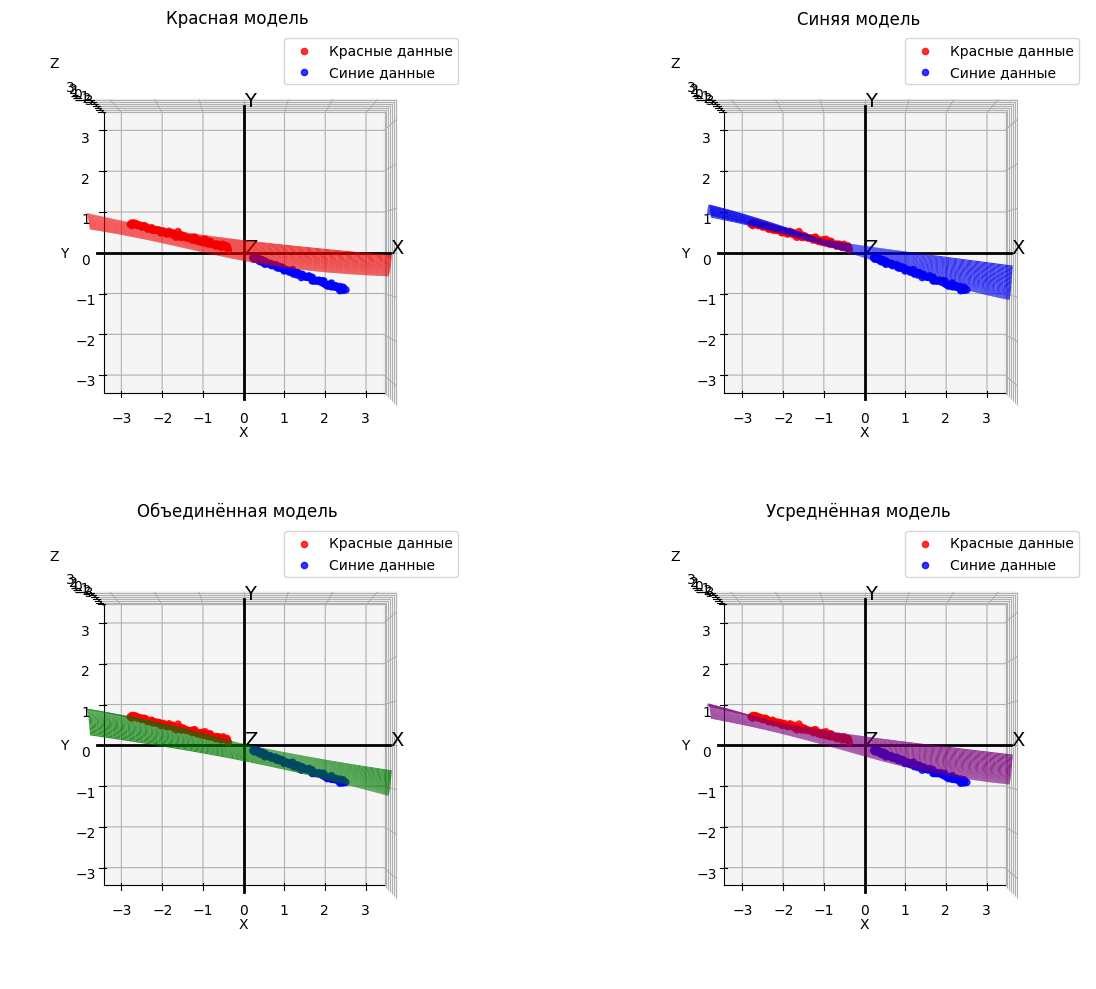

In [80]:
models_to_plot = [
    ("Красная модель", red_nn_predict, "red"),
    ("Синяя модель", blue_nn_predict, "blue"),
    ("Объединённая модель", combined_nn_predict_func, "green"),
    ("Усреднённая модель", averaged_nn_predict, "purple"),
]

fig = plt.figure(figsize=(14, 10))

# Общая длина осей
all_points = np.vstack([red_points, blue_points])

axis_len = max(
    abs(all_points[:, 0].min()),
    abs(all_points[:, 0].max()),
    abs(all_points[:, 1].min()),
    abs(all_points[:, 1].max()),
    abs(all_points[:, 2].min()),
    abs(all_points[:, 2].max()),
) * 1.3


def add_3d_axes(ax, axis_len):
    # Ось X
    ax.plot(
        [-axis_len, axis_len],
        [0, 0],
        [0, 0],
        color="black",
        linewidth=2
    )

    # Ось Y
    ax.plot(
        [0, 0],
        [-axis_len, axis_len],
        [0, 0],
        color="black",
        linewidth=2
    )

    # Ось Z
    ax.plot(
        [0, 0],
        [0, 0],
        [-axis_len, axis_len],
        color="black",
        linewidth=2
    )

    # Подписи осей
    ax.text(axis_len, 0, 0, "X", fontsize=14, color="black")
    ax.text(0, axis_len, 0, "Y", fontsize=14, color="black")
    ax.text(0, 0, axis_len, "Z", fontsize=14, color="black")


for idx, (model_name, predict_func, color) in enumerate(models_to_plot, start=1):
    ax = fig.add_subplot(2, 2, idx, projection="3d")

    X_s, Y_s, Z_s = make_surface_for_function(
        x_min, x_max,
        z_min, z_max,
        predict_func,
        n=40
    )

    # Красные данные
    ax.scatter(
        red_points[:, 0],
        red_points[:, 1],
        red_points[:, 2],
        color="red",
        s=20,
        alpha=0.8,
        label="Красные данные"
    )

    # Синие данные
    ax.scatter(
        blue_points[:, 0],
        blue_points[:, 1],
        blue_points[:, 2],
        color="blue",
        s=20,
        alpha=0.8,
        label="Синие данные"
    )

    # Поверхность модели
    ax.plot_surface(
        X_s,
        Y_s,
        Z_s,
        color=color,
        alpha=0.8,
        linewidth=1
    )

    # Добавляем оси X, Y, Z
    add_3d_axes(ax, axis_len)

    ax.set_title(model_name)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # Одинаковые пределы для всех графиков
    ax.set_xlim(-axis_len, axis_len)
    ax.set_ylim(-axis_len, axis_len)
    ax.set_zlim(-axis_len, axis_len)

    # Угол камеры
    ax.view_init(elev=90, azim=-90)
    ax.legend()

plt.tight_layout()
plt.show()

In [81]:
def print_desmos_formula_for_mlp(model, name="Объединённая модель"):
    W1 = model.coefs_[0]
    b1 = model.intercepts_[0]

    W2 = model.coefs_[1]
    b2 = model.intercepts_[1]

    # h1
    w11 = W1[0, 0]  # x -> h1
    w12 = W1[1, 0]  # z -> h1
    b_h1 = b1[0]

    # h2
    w21 = W1[0, 1]  # x -> h2
    w22 = W1[1, 1]  # z -> h2
    b_h2 = b1[1]

    # output
    v1 = W2[0, 0]
    v2 = W2[1, 0]
    c = b2[0]

    print(name)
    print()
    print(
        f"y = {v1:.6f}*tanh({w11:.6f}*x + {w12:.6f}*z + {b_h1:.6f}) "
        f"+ {v2:.6f}*tanh({w21:.6f}*x + {w22:.6f}*z + {b_h2:.6f}) "
        f"+ {c:.6f}"
    )

In [82]:
print_desmos_formula_for_mlp(
    combined_nn,
    name="Нейросеть, обученная на объединённых данных"
)

Нейросеть, обученная на объединённых данных

y = 1.362886*tanh(-0.096306*x + 0.499058*z + 0.295191) + 0.654166*tanh(-0.258195*x + -0.717978*z + 0.207361) + -0.556816


## Анализ

### Видно что 